# <p style="background-color:skyblue;font-family:newtimeroman;font-size:200%;color:white;text-align:center;border-radius:20px 20px;"><b> Hand Written Digits  SVM-DT-RF Project </b></p>

# WELCOME!

**Data reference link :**

https://journals.tubitak.gov.tr/cgi/viewcontent.cgi?article=3717&context=elektrik

https://archive.ics.uci.edu/dataset/81/pen+based+recognition+of+handwritten+digits

- El yazısı rakamlarını tanımak için kullanılan bir veri kümesidir. 

- Veri seti, el yazısı rakamlarının taranmış görüntülerini içerir

- Veri seti toplamda 10 sınıfa sahiptir ve her bir sınıf, 0 ile 9 arasındaki bir rakamı temsil eder. 

- 44 denekten 250şer veri alınmış. 

- Veri kümesi, görüntü verilerinin yanı sıra her bir görüntünün hangi rakamı temsil ettiği bilgisini de içerir.

- Bu veri kümesi, makine öğrenmesi algoritmalarının el yazısı tanıma konusundaki performanslarını değerlendirmek için sıkça kullanılır. 

- Ayrıca, derin öğrenme modellerinin eğitiminde kullanılan popüler bir veri kümesidir.

**El Yazısı Rakamların Kalem Tabanlı Tanınması**

- Toplam 44 yazardan 250 örnek toplayarak bir rakam veritabanı oluşturuyoruz. Eğitim, cross validation ve yazara bağlı test için 30 yazar tarafından yazılan örnekler, yazardan bağımsız test için ise diğer 14 yazar tarafından yazılan rakamlar kullanılmaktadır. Bu veri tabanı UNIPEN formatında da mevcuttur.

- Entegre bir LCD ekrana ve kablosuz bir kaleme sahip WACOM PL-100V basınca duyarlı bir tablet kullanıyoruz. Giriş ve görüntüleme alanları aynı yerde bulunmaktadır. Intel 486 tabanlı bir bilgisayarın seri portuna bağlanan bu tablet, el yazısı örneklerini toplamamızı sağlıyor. Tablet, $x$ ve $y$ tablet koordinatlarını ve kalemin basınç seviyesi değerlerini 100 milisaniyelik sabit zaman aralıklarında (örnekleme hızı) gönderir.

- Bu yazarlardan 500'e 500 tablet piksel çözünürlüğündeki kutulara rastgele sırayla 250 rakam yazmaları istenir. Denek sadece ilk giriş ekranları sırasında izlenir. Her ekranda, yazılacak rakamların üzerinde gösterildiği beş kutu bulunmaktadır. Deneklere sadece bu kutuların içine yazmaları söylenir. Eğer bir hata yaparlarsa ya da yazdıklarından memnun kalmazlarsa, ekrandaki bir düğmeyi kullanarak bir kutunun içeriğini temizlemeleri söylenir. Çoğu yazar bu tür giriş cihazlarına aşina olmadığı için ilk on rakam göz ardı edilir, ancak denekler bunun farkında değildir.

- Çalışmamızda sadece ($x, y$) koordinat bilgilerini kullanıyoruz. Kalem basınç seviyesi değerleri göz ardı edilmektedir. İlk olarak, temsilimizi ötelemelere ve ölçek bozulmalarına karşı değişmez hale getirmek için normalleştirme uyguluyoruz. Tabletten aldığımız ham veriler 0 ile 500 (tablet giriş kutusu çözünürlüğü) arasındaki tamsayı değerlerinden oluşmaktadır. Yeni koordinatlar, maksimum aralığa sahip koordinat 0 ile 100 arasında değişecek şekildedir. Çoğu karakter genişliğinden daha uzun olduğu için genellikle $x$ bu aralıkta kalır.

**Feature bilgileri**

Modellerimizi eğitmek ve test etmek için, rakamları sabit uzunlukta özellik vektörleri olarak temsil etmemiz gerekir. İyi sonuçlara yol açan yaygın olarak kullanılan bir teknik ( x_t, y_t) noktalarının yeniden örneklenmesidir. Burada zamansal yeniden örnekleme (zaman içinde düzenli aralıklarla yerleştirilmiş noktalar) veya uzamsal yeniden örnekleme (yay uzunluğu içinde düzenli aralıklarla yerleştirilmiş noktalar) kullanılabilir. Ham nokta verileri zaten zaman içinde düzenli aralıklarla yerleştirilmiştir ancak aralarındaki mesafe değişkendir. Önceki araştırmalar, yörünge üzerinde sabit sayıda düzenli aralıklı nokta elde etmek için uzamsal yeniden örneklemenin çok daha iyi performans verdiğini göstermiştir, çünkü noktalar arasında daha iyi bir hizalama sağlar. Yeniden örnekleme algoritmamız, nokta çiftleri arasında basit doğrusal enterpolasyon kullanır. Yeniden örneklenen rakamlar, zaman içinde düzenli aralıklarla yerleştirilmiş giriş dizisinin aksine, yay uzunluğunda düzenli aralıklarla yerleştirilmiş T noktalarından ( x_t, y_t )_{t=1}^T oluşan bir dizi olarak temsil edilir.

Dolayısıyla, giriş vektörü boyutu 2*T, yani yeniden örneklenen nokta sayısının iki katıdır. Deneylerimizde T=8,12,16 noktalarına uzamsal yeniden örnekleme yapmayı düşündük ve T=8'in doğruluk ve karmaşıklık arasında en iyi dengeyi sağladığını gördük.

# Exploratory Data Analysis

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score,f1_score, classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import  GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from yellowbrick.classifier import ClassPredictionError, ROCAUC

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

## Load Dataset

In [3]:
df = pd.read_csv("pendigits_txt.csv")
df.head()

# inputlar x-y kordinatları

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


## Explore Data

In [4]:
# Veri setinin genel bir profilini elde etmek için
# Gözlem sayısı-veri tipi-null değer sayısı-unique değer sayısı-min-max değerleri
# null değerler "0" gözüküyor!

def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    Min = df.min()
    Max = df.max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

summary(df)

Data shape: (10992, 17)
___________________________
Data Types:
Types
int64    17
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
class,int64,10992,10,0,0,9
input1,int64,10992,101,0,0,100
input10,int64,10992,101,0,0,100
input11,int64,10992,101,0,0,100
input12,int64,10992,101,0,0,100
input13,int64,10992,101,0,0,100
input14,int64,10992,101,0,0,100
input15,int64,10992,101,0,0,100
input16,int64,10992,101,0,0,100
input2,int64,10992,96,0,0,100


In [5]:
df.describe().T

# 2. ve 4. featurelar min-25% arası farklara dikkat !!

,count,mean,std,min,25%,50%,75%,max
input1,10992.0,38.814320,34.257783,0.0,6.0,32.0,65.0,100.0
input2,10992.0,85.120269,16.218571,0.0,76.0,89.0,100.0,100.0
input3,10992.0,40.605622,26.342984,0.0,20.0,40.0,58.0,100.0
input4,10992.0,83.774199,19.163646,0.0,72.0,91.0,100.0,100.0
input5,10992.0,49.770378,34.100515,0.0,18.0,53.0,78.0,100.0
input6,10992.0,65.573144,26.996688,0.0,49.0,71.0,86.0,100.0
input7,10992.0,51.220251,30.576881,0.0,28.0,53.5,74.0,100.0
input8,10992.0,44.498999,29.906104,0.0,23.0,43.0,64.0,100.0
input9,10992.0,56.868541,34.135530,0.0,29.0,60.0,89.0,100.0
input10,10992.0,33.695961,27.251548,0.0,7.0,33.0,54.0,100.0


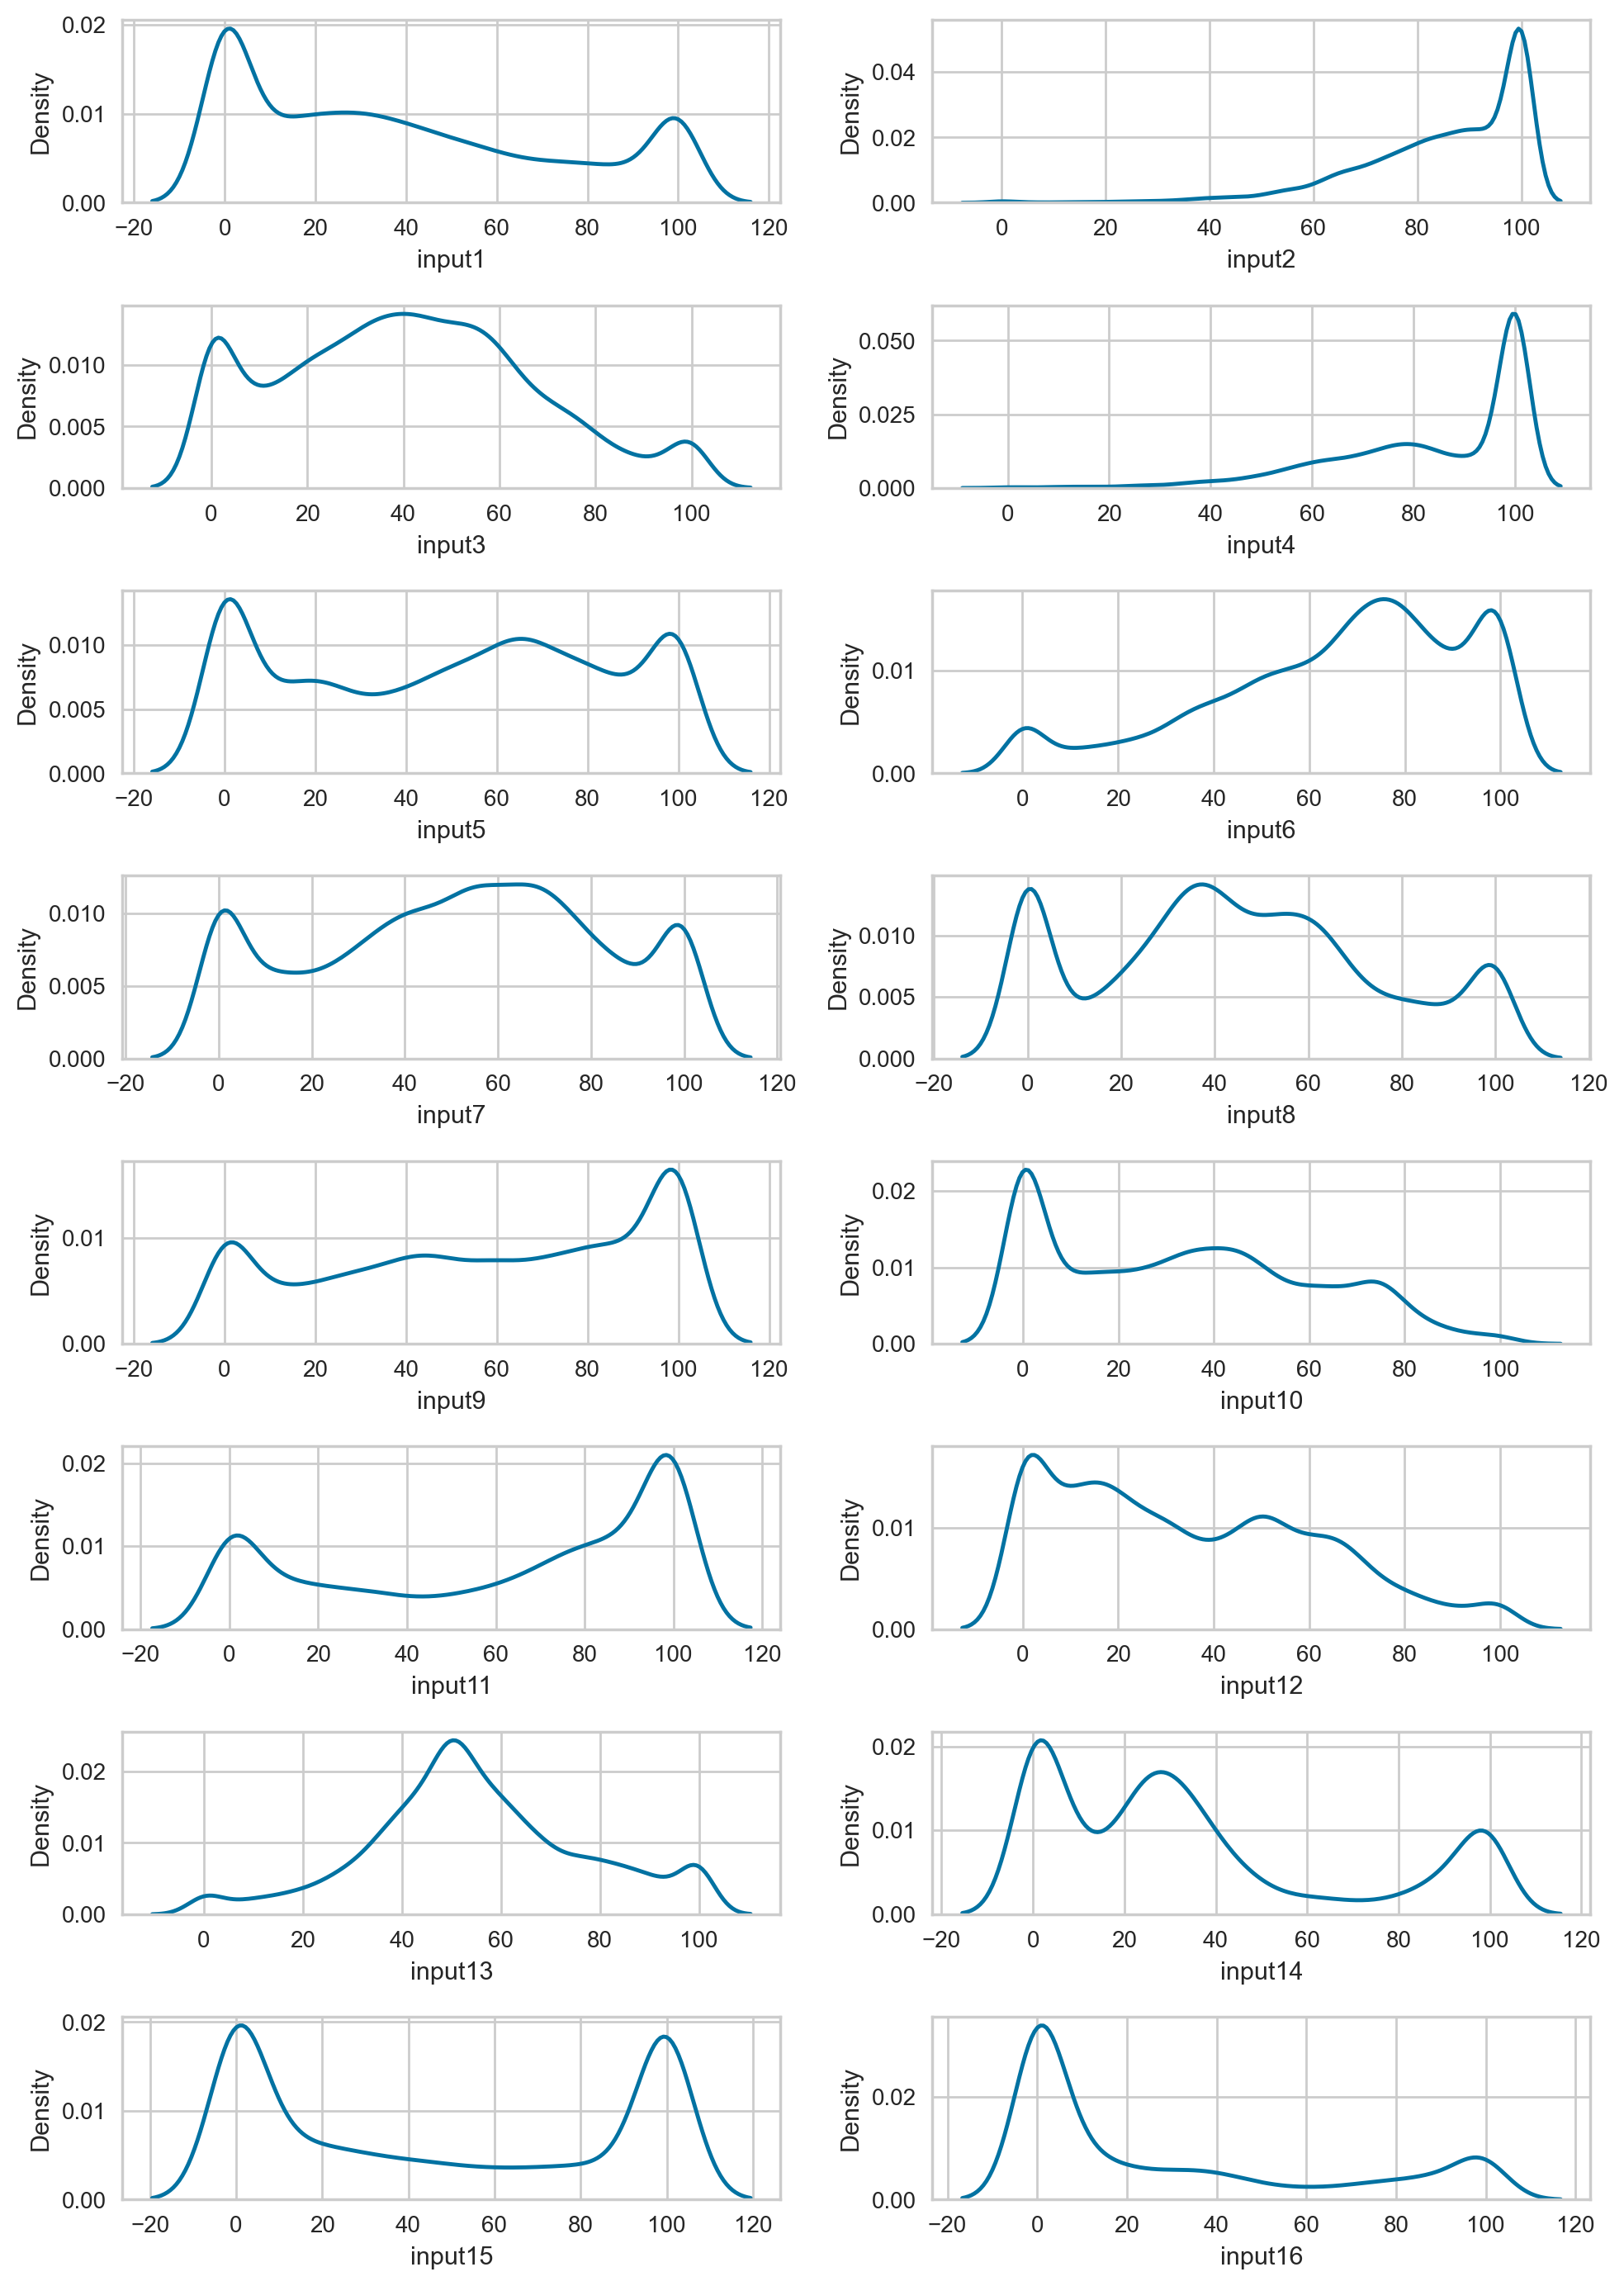

In [6]:
# Classlarımızı ayırmaya yarayacak bir insight ede edebilir miyiz ona bakıyoruz

fig = plt.figure(figsize=(10,14), dpi=200)
for i, col in enumerate(df.columns[:-1]):
        plt.subplot(8,2,i+1)
        sns.kdeplot(df[col])
plt.tight_layout();

- Bimodal normal distribution, normal bir dağılımın iki ayrı zirvesi olan bir dağılımdır. 

- Multimodal normal distribution, normal bir dağılımın üç veya daha fazla  zirvesi olan bir dağılımdır. 

- Bu tür bir dağılım, veri setinde iki farklı alt popülasyonun varlığını veya bir dış faktörün veri setindeki dağılımı etkilemiş olabileceğini gösterir.

- Bimodal-Multimodal normal distribution, birbirinden farklı alt popülasyonların ortalamaları ve standart sapmaları birbirinden önemli ölçüde farklı olduğunda ortaya çıkabilir.

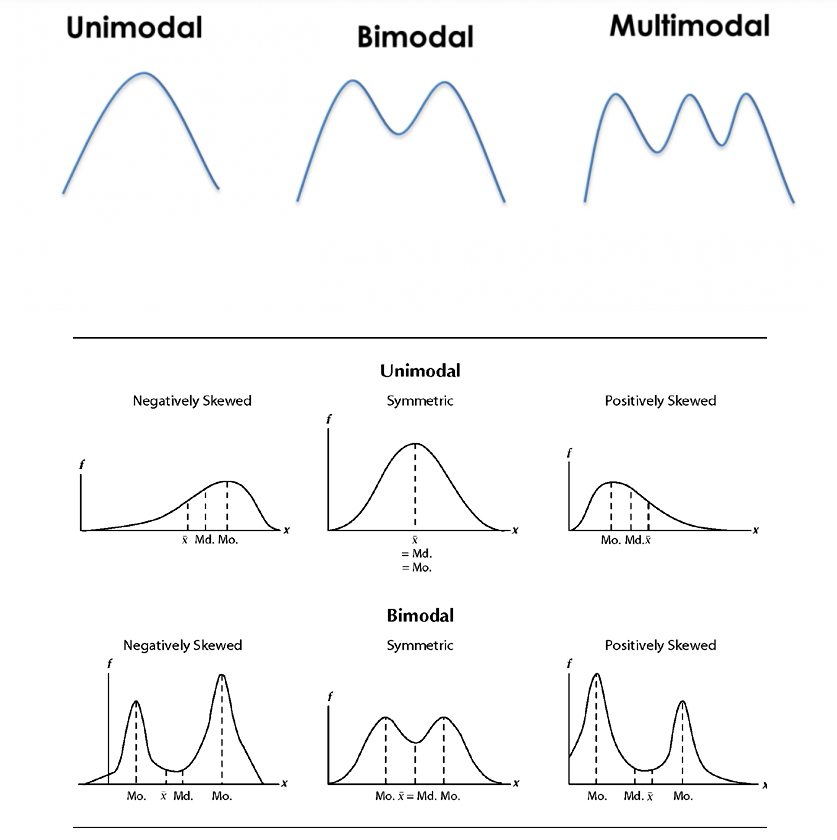

## 2.  Data Cleaning

### Detect Missing Values and Outliers

**Outlierlere Duyarlı Olmayan veya Az Duyarlı Olan Algoritmalar:**

1. **Support Vector Machine (SVM):** SVM, marjinleri maksimize ederek çalışır ve marjin içindeki noktaları (outlierlar dahil) ihmal eder. Bu, SVM'in bazı durumlarda outlierlere karşı dayanıklı olmasını sağlar.

2. **Decision Tree:** Decision Tree bölme kriterleri üzerine kuruludur ve bu bölme kriterleri genellikle outlierlardan etkilenmez. Ancak, çok fazla outlier varsa, ağacın yapısı ve sonuçta elde edilen karar sınırları etkilenebilir.

3. **Random Forest:** Deision Tree ye benzer şekilde çalışır ve birden fazla ağacın birleştirilmesiyle oluşur. Bu birleştirme işlemi, outlierların etkisini azaltır.

4. **Yapay Sinir Ağları:** Sinir ağları karmaşıklıkları ve öğrenme kapasiteleri nedeniyle bazen outlierlara karşı dayanıklı olabilir, ancak bu, ağın mimarisine ve eğitim verisine bağlıdır. Ayrıca, aşırı eğitilmiş bir model outlierlara duyarlı olabilir.

**Outlierlere Duyarlı Olan Algoritmalar:**

1. **K-Means Clustering (K-Means):** K-Means algoritması, ortalama hesaplaması yaptığı için outlierlardan çok etkilenir. Outlierlar, küme merkezlerinin konumunu önemli ölçüde değiştirebilir.

2. **Hierarchical Clustering:** Bu yöntem de benzer şekilde outlierlardan etkilenebilir, çünkü kümeleme süreci sırasında outlierlar dengesiz küme yapılarına neden olabilir.

3. **Lineer Regresyon:** Lineer regresyon, outlierlardan etkilenebilir çünkü bu noktalar regresyon çizgisinin yönünü önemli ölçüde değiştirebilir.

4. **Logistik Regresyon:** Logistik regresyon, outlierlardan etkilenebilir, çünkü bu noktalar modelin tahmin sınırını bozabilir.

5. **Ridge Regresyon ve Lasso Regresyon:** Her iki yöntem de regülarizasyon içerir. Ridge ve Lasso, lineer regresyonun outlierlara duyarlılığını azaltabilir, ancak bu yöntemler hala outlierlardan etkilenebilir.

6. **ElasticNet Regresyon:** ElasticNet, Ridge ve Lasso'nun bir kombinasyonudur ve yukarıdakilere benzer şekilde outlierlara karşı hassasiyet gösterebilir.

In [7]:
df.isnull().sum().any()  # missing value yok

False

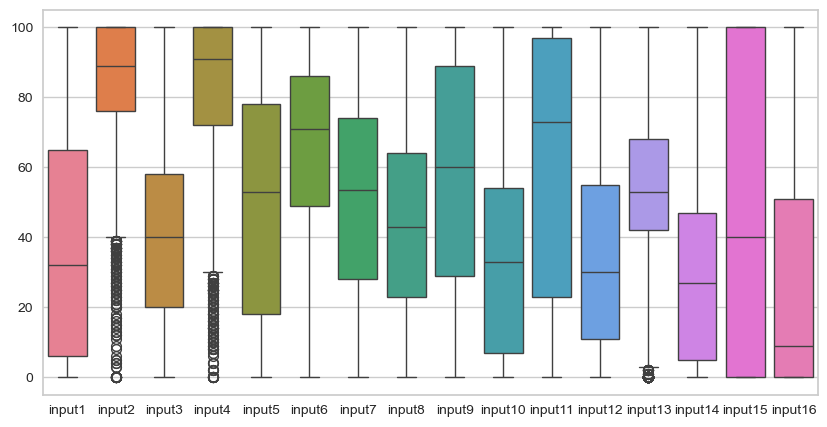

In [8]:
# outlier detection yapıyoruz, bütün featurelar için boxplotlarını çizdiriyoruz
# 2-4 ve 13. featurelar için outlier görülüyor 

plt.figure(figsize=(10,5))
sns.boxplot(data=df.drop("class", axis=1));

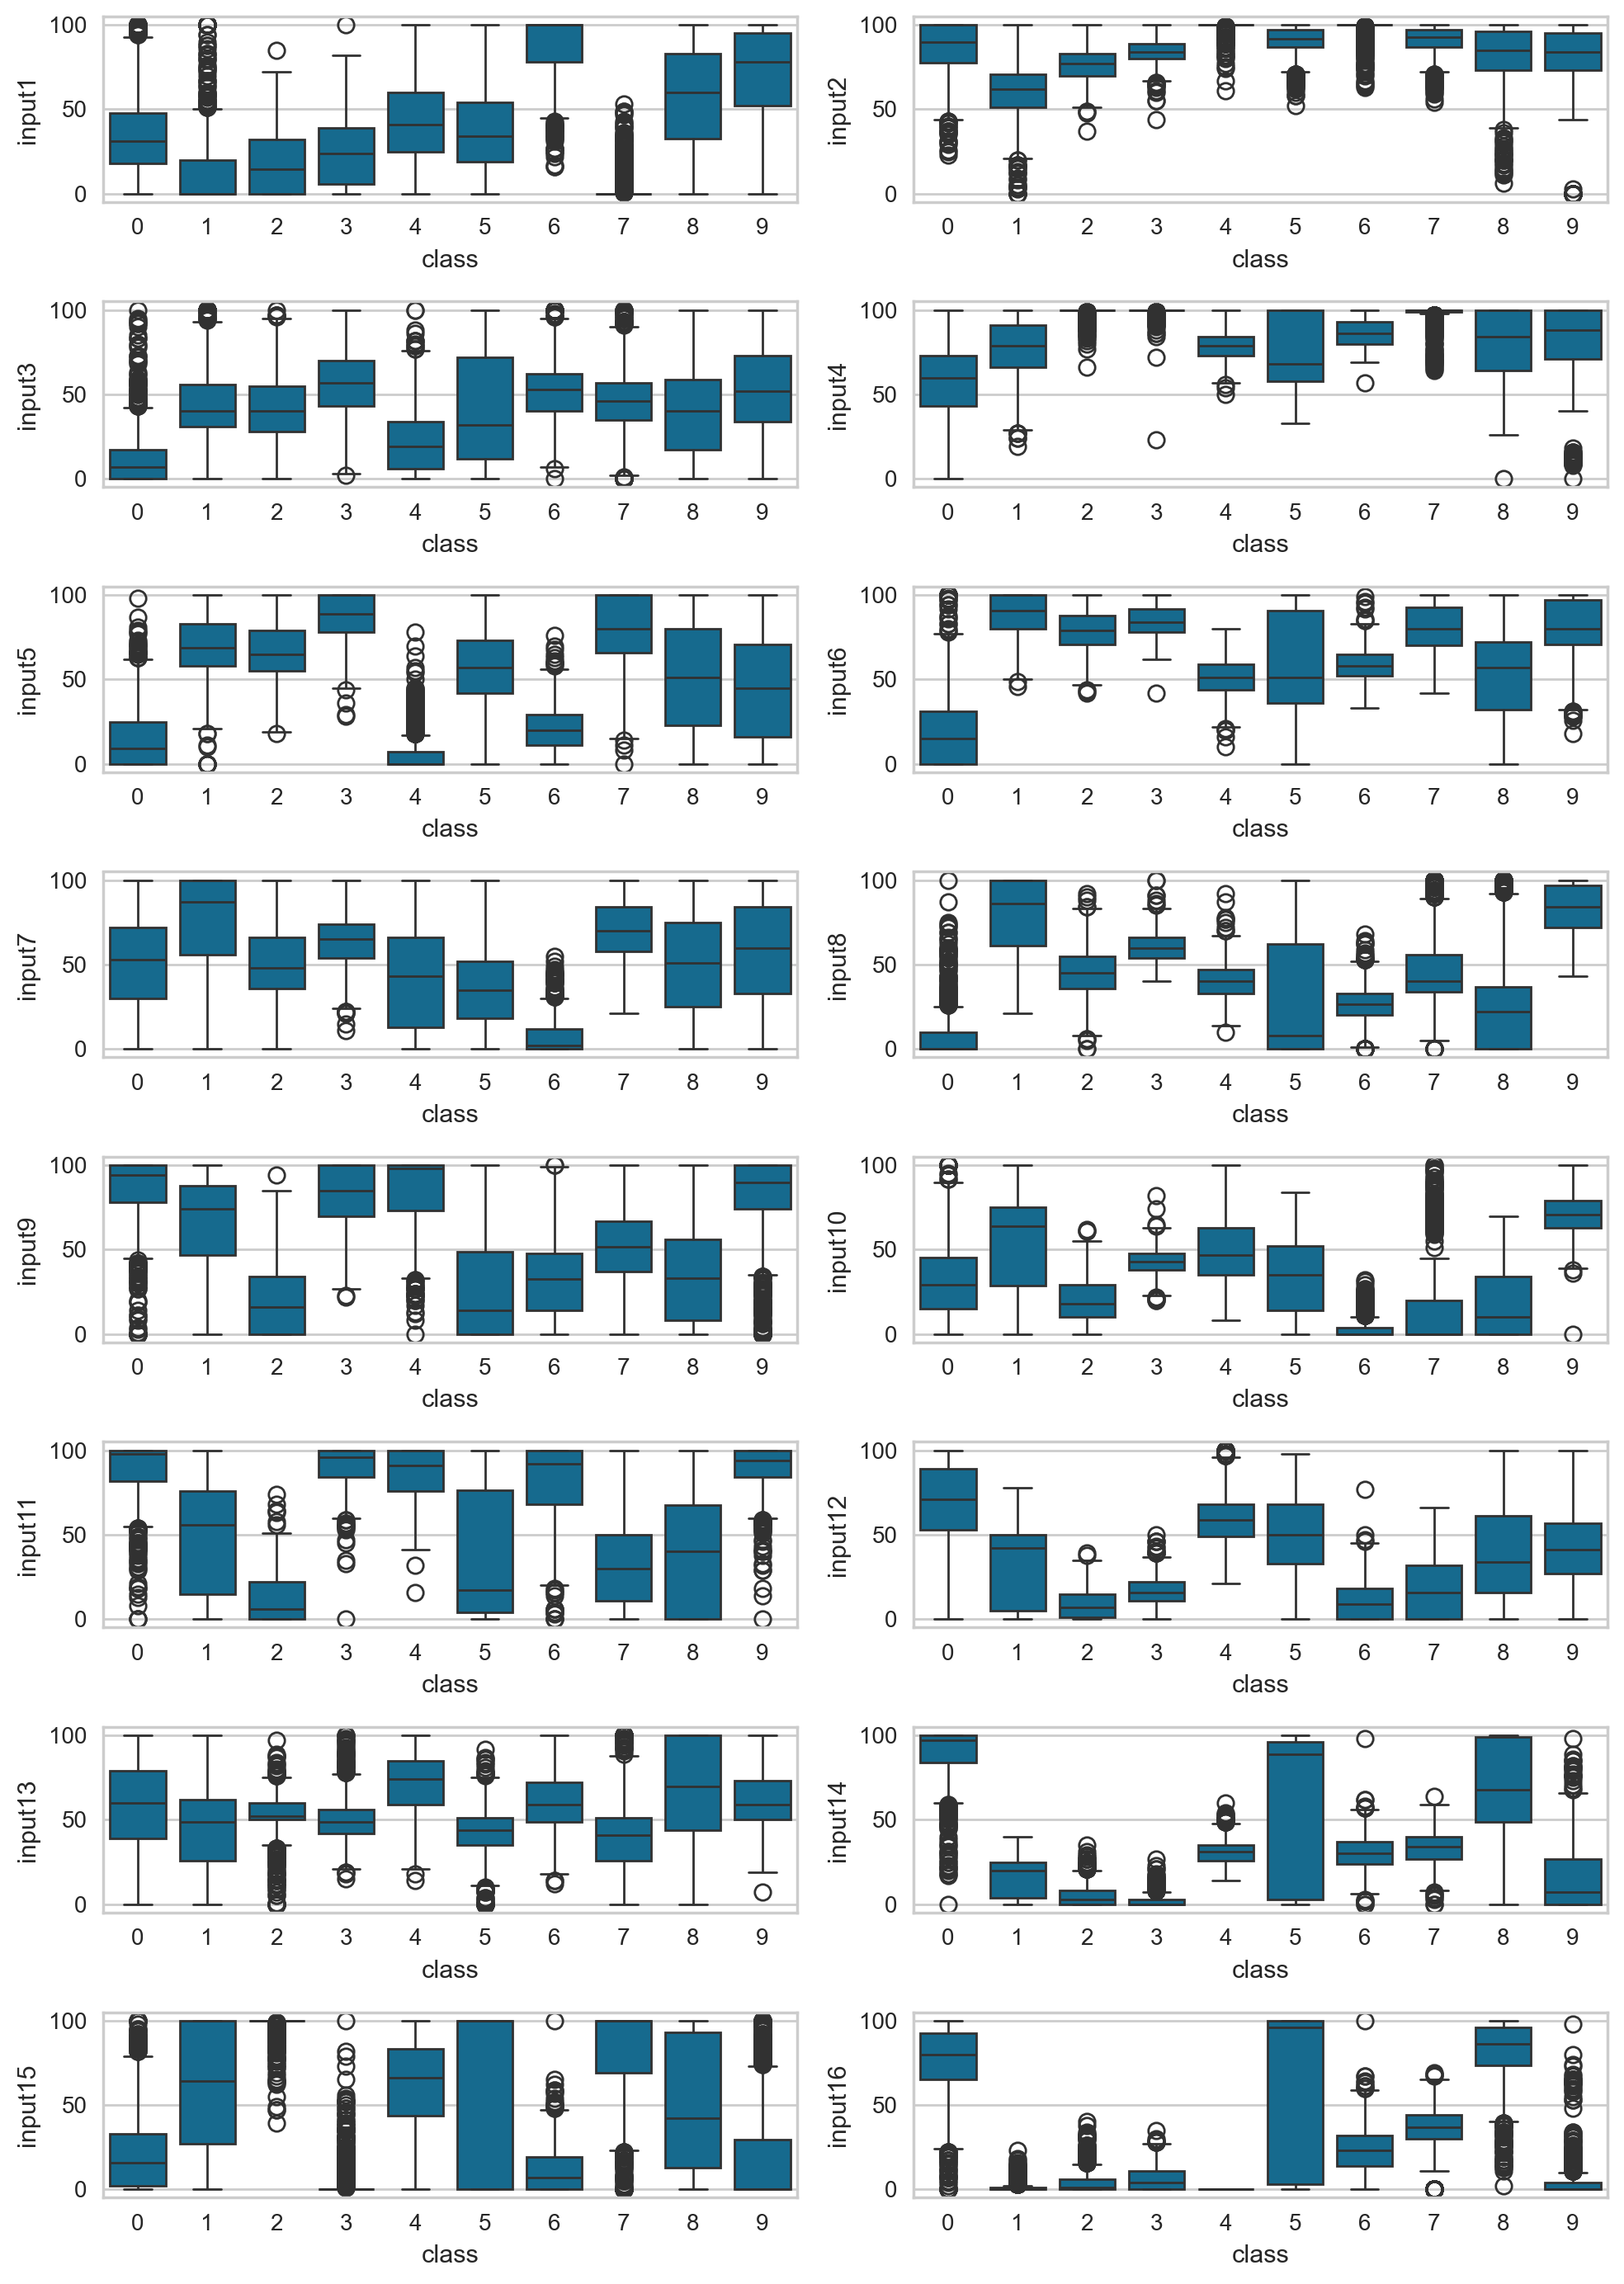

In [9]:
# yukardaki outlier değer içeren featurlardan emin olmak için classlar bazında her bir featurenın boxplotunu çiziyoruz
# kesin karar vermek için IQR değerlerine bakmak lazım 

fig = plt.figure(figsize=(10,14), dpi=200)
for i, col in enumerate(df.columns[:-1]):
        plt.subplot(8,2,i+1)
        sns.boxplot(y= df[col], x = df["class"], data=df)
plt.tight_layout();

**IQR hesaplamak için şu adımlar izlenir:**

- Veriler küçükten büyüğe sıralanır.
- Verilerin %25'ini ve %75'ini temsil eden ilk ve üçüncü çeyrekler hesaplanır.
- IQR, üçüncü çeyrekten ilk çeyrek çıkarılarak elde edilir.

Kod, öncelikle pandas DataFrame'inin belirli bir sütunundaki değerleri bir Numpy array'e dönüştürür (tolist() fonksiyonu ile)
daha sonra np.percentile() fonksiyonunu kullanarak bu array'deki belirtilen sütunun 25. persentil değerini hesaplar. 
Bu değer first_quartile değişkenine atanır.

**Tukey**, istatistiksel veri analizinde kullanılan bir kavramdır, aykırı değerleri tespit etmek için kullanılır.

IQR'nin kaç katı kadar uzaklıkta bir değerin aykırı kabul edileceğini belirleyen bir katsayı. Varsayılan değer 1.5'tir.

Bu, alt çeyrek ve üst çeyrek arasındaki mesafenin 1.5 katından daha uzakta olan verilerin aykırı değer olarak kabul edileceği anlamına gelir.

Fonksiyon, sütun verilerinin IQR'sini hesaplar, daha sonra belirtilen tukey katsayısıyla çarpılarak alt ve üst sınırları hesaplar. 

Daha sonra, verileri döngüde gezinerek her bir değerin alt ve üst sınırların dışında olup olmadığını kontrol eder ve bu değerleri bir sayaçla sayar.

In [10]:
# Sırasıyla her sınıf için aykırı değerlerin sayısını almak için bir fonksiyon üretebiliriz. 
# Pratiklik adına, sınıf ayrımını dikkate almadan özellikler için aykırı değerler buluyoruz.

def detect_outliers(df, col_name,tukey=1.5):
    ''' 
    this function detects outliers based on 1.5 time IQR and
    returns the number of lower and uper limit and number of outliers respectively
    '''
    first_quartile = np.percentile(np.array(df[col_name].tolist()), 25)
    third_quartile = np.percentile(np.array(df[col_name].tolist()), 75)
    IQR = third_quartile - first_quartile
                      
    upper_limit = third_quartile+(tukey*IQR)
    lower_limit = first_quartile-(tukey*IQR)
    outlier_count = 0
                      
    for value in df[col_name].tolist():
        if (value < lower_limit) | (value > upper_limit):
            outlier_count +=1
    return lower_limit, upper_limit, outlier_count

In [11]:
# biz burda threshold umuzu yani tukey imizi 1.5 belirliyoruz

threshold = 1.5
out_cols = []
for col in df.columns:
    print(
        f"{col}\nlower:{detect_outliers(df, col,threshold)[0]} \nupper:{detect_outliers(df, col,threshold)[1]}\
        \noutlier:{detect_outliers(df, col,threshold)[2]}\n*-*-*-*-*-*-*"
    )
    if detect_outliers(df, col,threshold)[2] > 0 :
        out_cols.append(col)
print(out_cols)        

input1
lower:-82.5 
upper:153.5        
outlier:0
*-*-*-*-*-*-*
input2
lower:40.0 
upper:136.0        
outlier:196
*-*-*-*-*-*-*
input3
lower:-37.0 
upper:115.0        
outlier:0
*-*-*-*-*-*-*
input4
lower:30.0 
upper:142.0        
outlier:153
*-*-*-*-*-*-*
input5
lower:-72.0 
upper:168.0        
outlier:0
*-*-*-*-*-*-*
input6
lower:-6.5 
upper:141.5        
outlier:0
*-*-*-*-*-*-*
input7
lower:-41.0 
upper:143.0        
outlier:0
*-*-*-*-*-*-*
input8
lower:-38.5 
upper:125.5        
outlier:0
*-*-*-*-*-*-*
input9
lower:-61.0 
upper:179.0        
outlier:0
*-*-*-*-*-*-*
input10
lower:-63.5 
upper:124.5        
outlier:0
*-*-*-*-*-*-*
input11
lower:-88.0 
upper:208.0        
outlier:0
*-*-*-*-*-*-*
input12
lower:-55.0 
upper:121.0        
outlier:0
*-*-*-*-*-*-*
input13
lower:3.0 
upper:107.0        
outlier:208
*-*-*-*-*-*-*
input14
lower:-58.0 
upper:110.0        
outlier:0
*-*-*-*-*-*-*
input15
lower:-150.0 
upper:250.0        
outlier:0
*-*-*-*-*-*-*
input16
lower:-76.5 
upper:127.5

In [12]:
out_cols

['input2', 'input4', 'input13']

In [13]:
df1 = df.copy()       # outlier ları düşersek ne olur

In [14]:
# 1,5 IQR üzerindeki aykırı değerleri düşürmek için

for col in out_cols:
    df1 = df1[(df1[col] > detect_outliers(df1, col)[0])
             & (df1[col] < detect_outliers(df1, col)[1])]

In [15]:
df1.shape

(10450, 17)

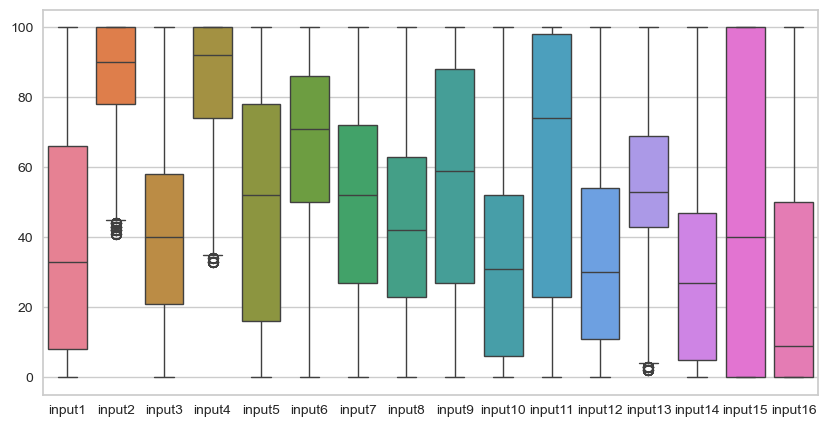

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df1.drop("class", axis=1));

In [17]:
len(df) - len(df1)

542

### My target column is `class`. So let's take a close look at this column.

In [18]:
# class sütununda 0'dan 9'a kadar olan değerlerin kaçar kez tekrar ettiğini yazdırır.

for i in range(0,10) :
    print(f"the number of {i}--->{df[df['class'] == i].shape[0]}")

the number of 0--->1143
the number of 1--->1143
the number of 2--->1144
the number of 3--->1055
the number of 4--->1144
the number of 5--->1055
the number of 6--->1056
the number of 7--->1142
the number of 8--->1055
the number of 9--->1055


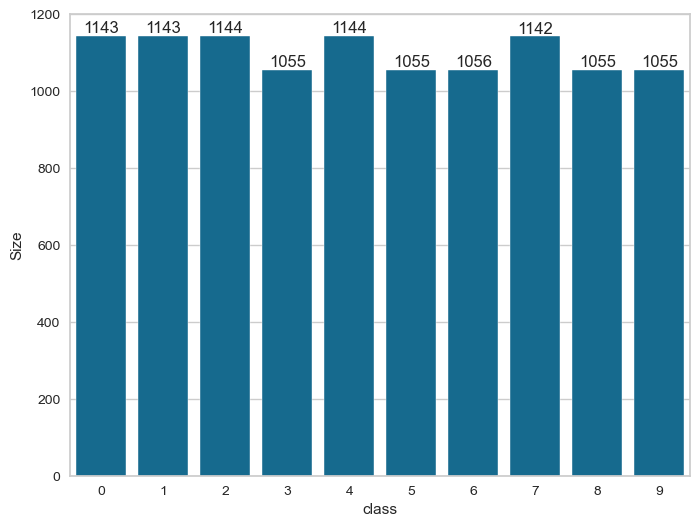

In [19]:
# Dengeli verilere (sınıf) sahip olduğumuzu görebiliriz. 
# Ancak, ek olarak, her sınıfın yüzdelik dağılımını kontrol etmek istiyorum.

class_digit = df.groupby('class').size()
class_label = pd.DataFrame(class_digit,columns = ['Size'])
plt.figure(figsize = (8,6))
ax= sns.barplot(x = class_label.index, y = 'Size', data = class_label)
plt.bar_label(ax.containers[0]);

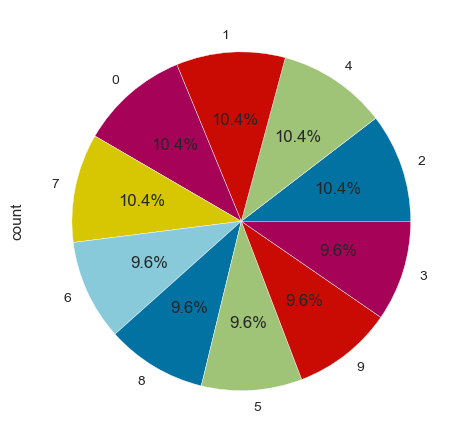

In [20]:
df["class"].value_counts().plot.pie(autopct='%1.1f%%');

### Now, let's take a closer look at correlation of continuous columns.

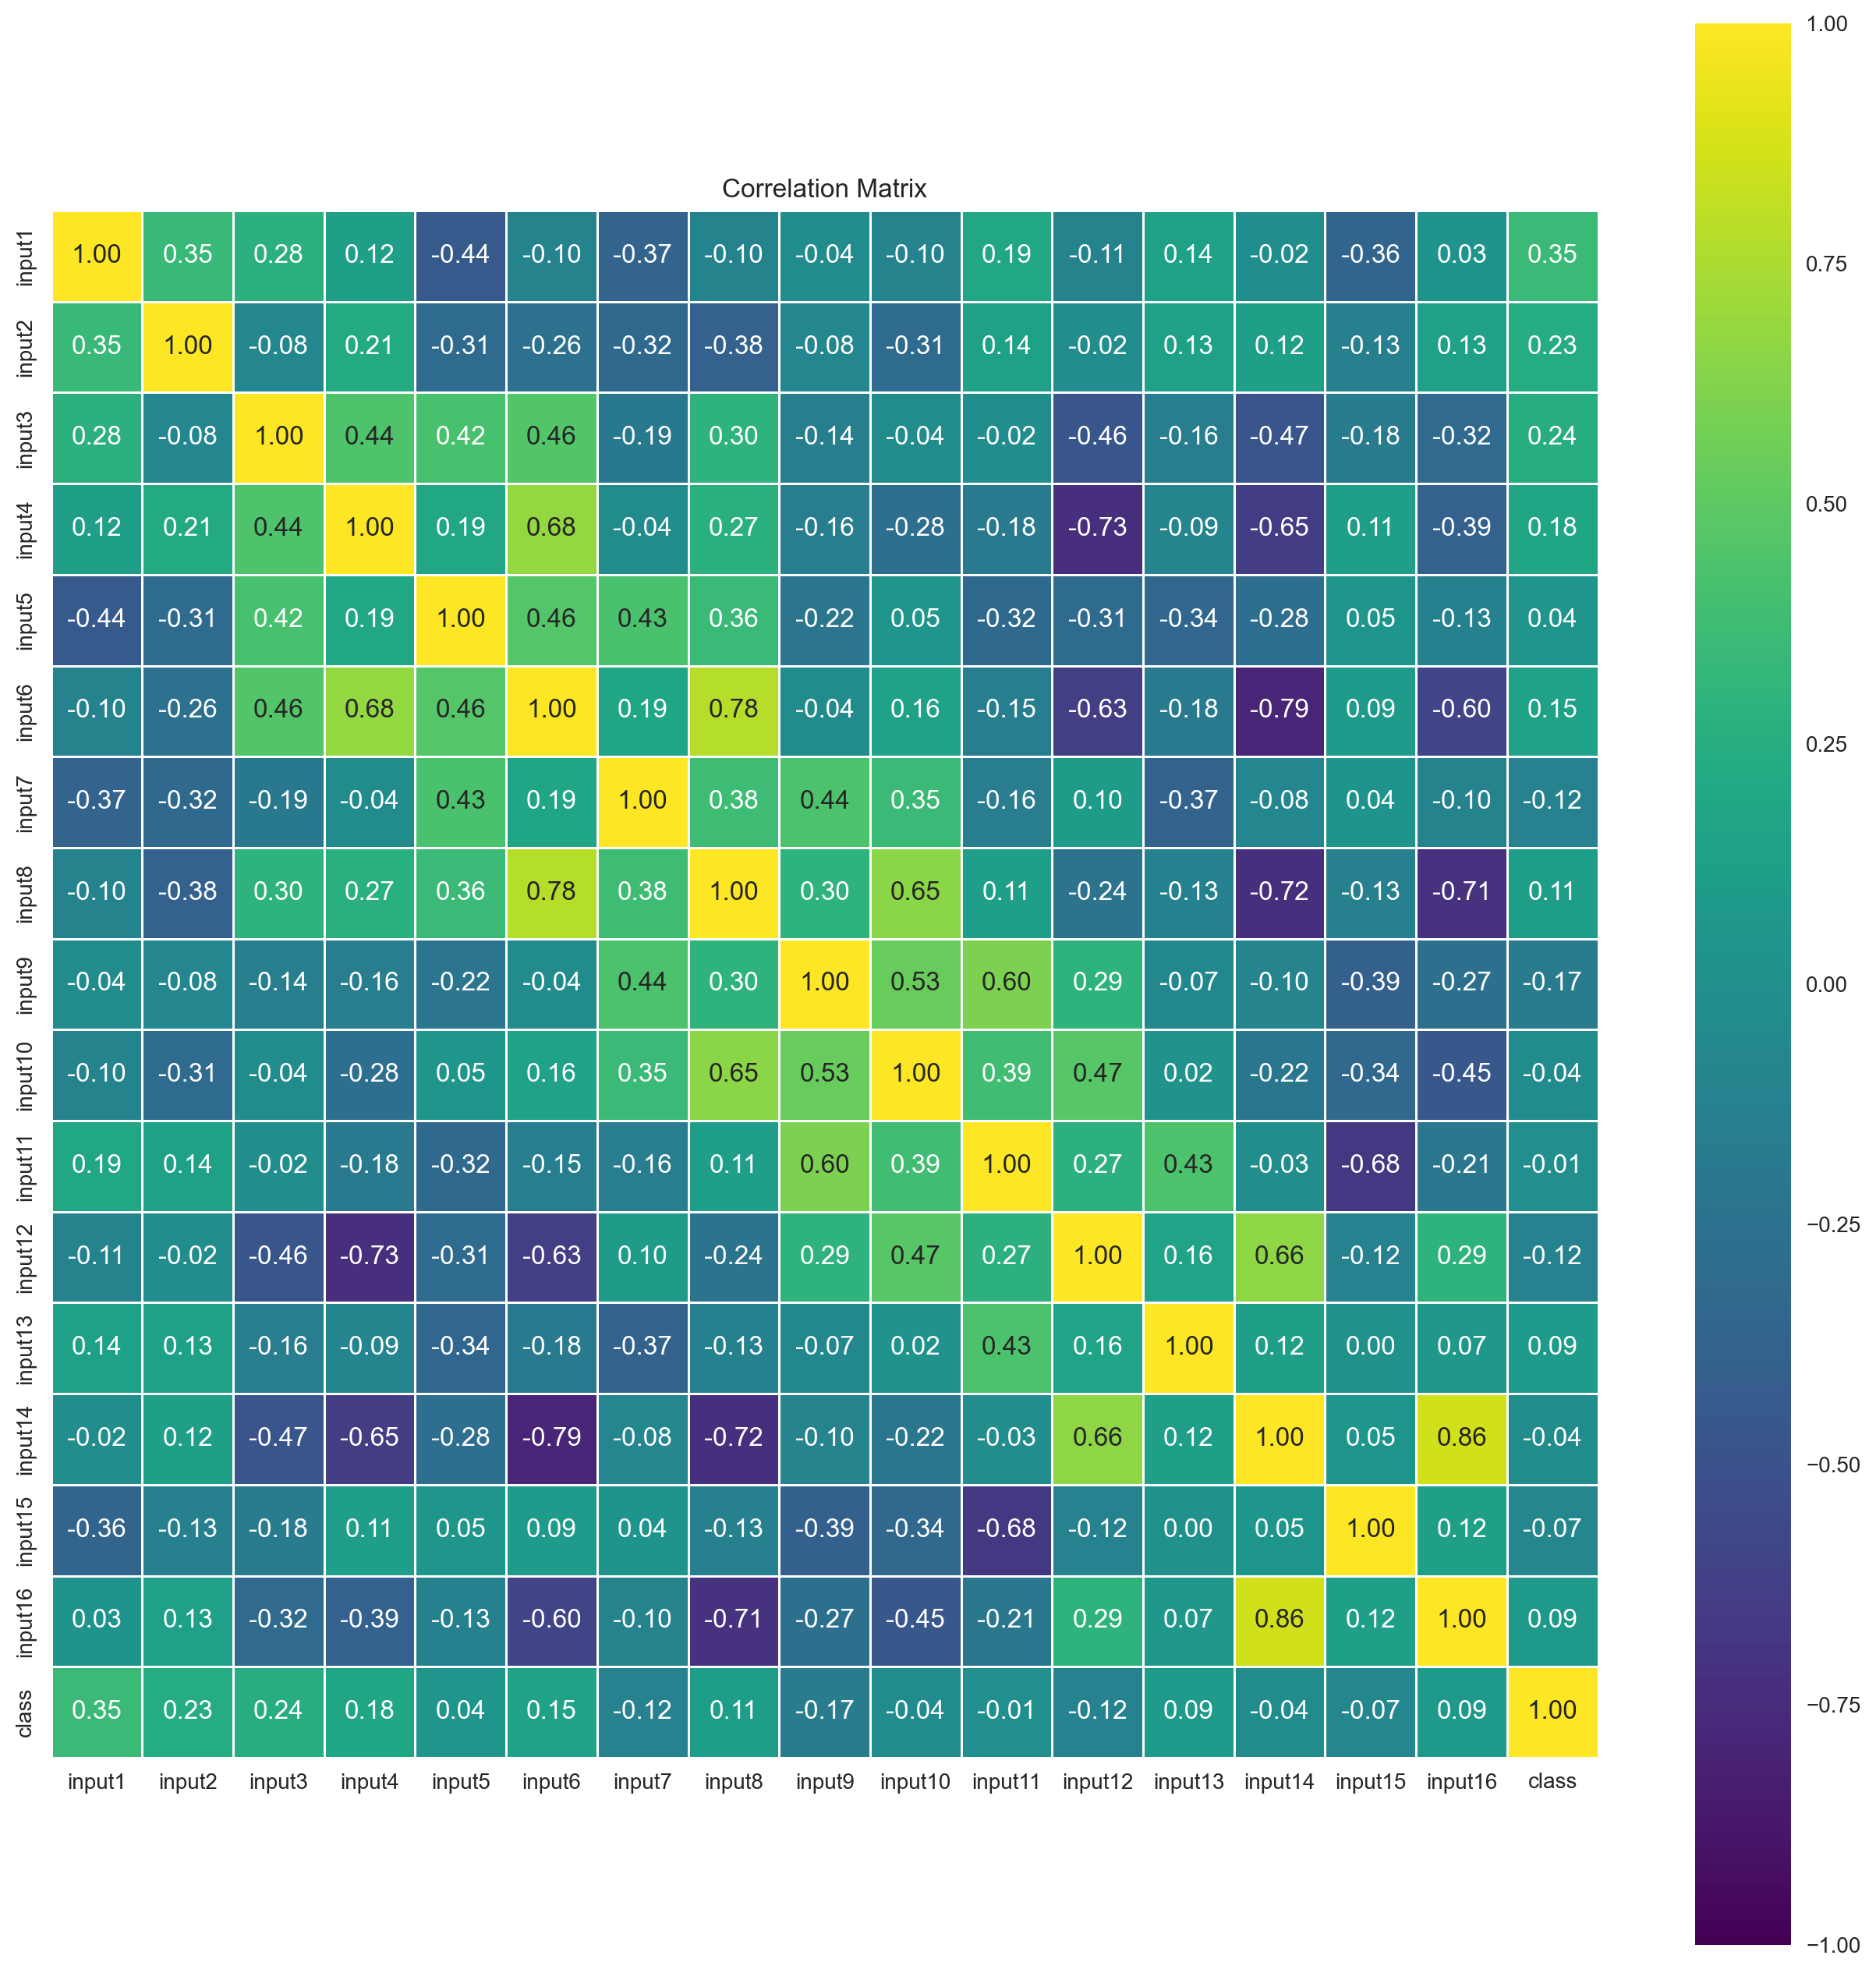

In [21]:
# 0.80 in altında üstünde bir korelasyon yok
# olsa da tree based modellerde multikolinarity sorun değil

corr_matrix = df.corr()

plt.figure(figsize=(16, 16), dpi=200)
sns.heatmap(corr_matrix,square=True, annot=True, fmt=".2f", annot_kws={"size": 12}, linewidths=.5, vmin=-1, vmax=1, cmap='viridis')
plt.title("Correlation Matrix")

plt.show();

In [22]:
# Data setimizi ara ara csv dosyası olarak kaydetmek iyidir, özellikle EDA sonrası sıfırdan çalıştırmak zorunda kalmayız

df.to_csv("handdigit_EDA.csv", index = False)

# index=False parametresi, indeks sütununu dahil etmeden df in diğer sütunlarını CSV dosyasına aktarır. 
# Bu parametre, dosyanın daha düzenli ve anlaşılır olmasını sağlar.

# Multi-class Classification

### Data Preprocessing

In [23]:
df = pd.read_csv("handdigit_EDA.csv")

In [24]:
df.head()

,input1,input2,input3,input4,input5,input6,input7,input8,input9,input10,input11,input12,input13,input14,input15,input16,class
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98,8
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6,2
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0,1
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0,4
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0,1


In [25]:
X = df.drop("class", axis = 1)
y = df["class"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

# "shuffle=False" parametresi, verilerin rastgele karıştırılmadan doğrudan bölmeler oluşturmasını sağlar 
# shuffle default True, karıştırıp öyle train-test split yapar
# Sınıflar üzerinden data leakege i önlemek için shuffle yapmadan karıştırmadan ayırmamız gerekiyor
# Shuffle kullanırsak aynı kişiden aynı yazılı rakamlar her ikisinde de olabilir
# test ve tren tarafı ve setler arasında çakışma, leaky validation a (sızdıran doğrulamaya) neden olur
# Bu parametre, özellikle kronolojik sıraya sahip verilerle -finansal zaman serileri gibi-çalışırken kullanışlıdır

## Implement Support Vector Machine



**SVM (Support Vector Machine)**, bir sınıflandırma ve regresyon algoritmasıdır. 

- Küçük veya orta büyüklükteki veri setleri için uygundur. 

- Distance base bir model olduğundan Scale’e duyarlıdır. Scale edilmesi gerekir.

- SVM'nin temel mantığı, verileri sınıflandırmak için verileri en iyi şekilde ayrıştıran bir hyperplane (hiperdüzlem) bulmaktır. 

- SVM, verileri bir uzayda temsil eder ve bu uzayda bir veya daha fazla hyperplane ile sınırları belirler. Hyperplane, verileri iki sınıfa ayıran en iyi ayrım çizgisidir. Bu çizgi, sınıflar arasındaki en büyük mesafeyi (margin) sağlamalıdır. SVM, bu margin mesafesini en büyük yapmak için çalışır.

- SVM ayrıca, doğrusal olmayan verilerle çalışırken kernel fonksiyonları kullanır. Kernel fonksiyonları, verilerin yüksek boyutlu uzaylarda temsil edilmesine izin verir. SVM, bu şekilde, daha karmaşık ve doğrusal olmayan verileri sınıflandırmak için daha yüksek doğruluk sağlar.

https://towardsdatascience.com/hyperparameter-tuning-for-support-vector-machines-c-and-gamma-parameters-6a5097416167
https://medium.com/grabngoinfo/support-vector-machine-svm-hyperparameter-tuning-in-python-a65586289bcb

**Peki Multiclass Olursa Ne Olur??**
- SVM algoritması, binary sınıflandırma için tasarlanmıştır. Ancak, multiclass sınıflandırma problemleri için de kullanılabilir. SVM, multiclass sınıflandırma problemlerinde birden fazla binary sınıflandırıcı kullanarak çalışır.

- Bu yaklaşım, "one-vs-all (rest)" (OvR) hepsine karşı bir veya "one-vs-one" (OvO) bire bir olarak bilinir. 

- OvA yaklaşımı, her sınıfın geri kalan tüm sınıflardan ayrı olarak ele alındığı ve sınıflandırıcının her sınıfı diğerlerinden ayırt etmeye çalıştığı bir yaklaşımdır. OvO yaklaşımı, her iki sınıf arasında bir sınıflandırıcı oluşturulur ve tüm sınıflandırıcıların çıktıları bir araya getirilerek en sık tekrarlanan sınıf belirlenir.

- Örneğin, 3 sınıflı bir sınıflandırma problemi için OvA yaklaşımı, önce sınıf 1'i diğerlerinden ayırmaya çalışan bir sınıflandırıcı oluşturur, ardından sınıf 2'yi diğerlerinden ayırmaya çalışan bir sınıflandırıcı oluşturur ve son olarak sınıf 3'ü diğerlerinden ayırmaya çalışan bir sınıflandırıcı oluşturur. Her sınıf için oluşturulan sınıflandırıcının çıktıları, hangi sınıfa ait olduğunu belirlemek için birleştirilir.

- OvO yaklaşımı ise her iki sınıf arasında bir sınıflandırıcı oluşturarak çalışır. Örneğin, 3 sınıflı bir sınıflandırma problemi için, sınıf 1 ve sınıf 2 arasında bir sınıflandırıcı, sınıf 1 ve sınıf 3 arasında bir sınıflandırıcı ve sınıf 2 ve sınıf 3 arasında bir sınıflandırıcı oluşturulur. Sonuç olarak, her bir çift sınıf arasındaki sınıflandırıcının çıktıları birleştirilir ve en sık tekrarlanan sınıf belirlenir.

https://www.baeldung.com/cs/svm-multiclass-classification

https://www.analyticsvidhya.com/blog/2021/05/multiclass-classification-using-svm/

https://towardsdatascience.com/multiclass-classification-with-support-vector-machines-svm-kernel-trick-kernel-functions-f9d5377d6f02   

### Vanilla SVC

In [27]:
scaler = MinMaxScaler()           # pipeline içerisinde kullanmak için tanımlıyoruz

In [28]:
SVM_model =  SVC(kernel="rbf", random_state=101)     # pipeline içerisinde kullanmak için tanımlıyoruz   # default=rbf

# RBF (Radial Basis Function); her bir noktanın belirli bir noktaya ne kadar benzediğini normal dağılım ile hesaplayan,
# ona göre sınıflandıran Kernel Trick metodu.
# iki örnek arasındaki benzerliği ölçmek için kullanılır. 
# Özellikle doğrusal olarak ayrılamayan veri setleri için oldukça kullanışlıdır.
# RBF çekirdeği, veriyi daha yüksek boyutlu bir uzaya dönüştürerek, bu yüksek boyutlu uzayda doğrusal bir sınıflandırma
# sınırı oluşturmaya yardımcı olur. 
# Bu, SVM'in doğrusal olarak ayrılamayan problemleri bile çözebilmesini sağlar.

In [29]:
from sklearn.pipeline  import Pipeline

SVM_model = Pipeline([("scaler",scaler),("SVM",SVM_model)])

# pipeline, modelin adımlarını birleştirmek için kullanılır.

In [30]:
SVM_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', MinMaxScaler()), ('SVM', SVC(random_state=101))])

In [31]:
# overitting kontrolü için hem train hem de test datasından predict alıyoruz

y_pred_test = SVM_model.predict(X_test)
y_pred_train = SVM_model.predict(X_train)

**Multiclass Sınıflandırmada Performans Değerlendirme**

 - Makine öğrenmesi modellerini değerlendirirken, modelin ne kadar başarılı olduğunu anlamak için farklı metrikler kullanırız.

 - Özellikle multiclass sınıflandırma problemlerinde (birden fazla sınıfın olduğu durumlar), performans değerlendirmesi biraz daha karmaşık hale gelir. Bu noktada, **average parametresi** devreye girer ve farklı sınıfların performansını nasıl bir araya getireceğimizi belirler.

**Farklı Average Yöntemleri:**

**Macro Average:** Her sınıf için hesaplanan metriğin (örneğin, F1-score) ortalamasını alır. Bu yöntem, tüm sınıfların eşit derecede önemli olduğu ve sınıf dengesizliğinin (bazı sınıfların çok daha fazla örneğe sahip olması) problem yaratabileceği durumlarda tercih edilir. Her sınıf için ayrı ayrı performans metriği hesaplanır ve ardından bu metriklerin aritmetik ortalaması alınır. 

**Micro Average:** Tüm sınıfların katkılarını bir araya getirerek tek bir metrik hesaplar. Bu yöntem, sınıf dengesizliğinin önemli olmadığı ve genel performansa odaklanmak istediğimiz durumlarda kullanılır. Büyük sınıflara daha fazla ağırlık verir. Tüm sınıfların toplam doğru tahminleri, yanlış pozitifleri ve yanlış negatifleri hesaplanır ve ardından bu toplamlar kullanılarak tek bir metrik hesaplanır.

**Weighted Average:** Her sınıfın metriğini, o sınıfın veri setindeki örnek sayısıyla orantılı olarak ağırlıklandırır. Bu yöntem, sınıf dengesizliğini hesaba katarken her sınıfın önemini de dikkate almak istediğimizde kullanılır. Her sınıf için ayrı ayrı performans metriği hesaplanır ve ardından bu metrikler, her sınıfın veri setindeki oranıyla orantılı olarak ağırlıklandırılarak ortalaması alınır. 

**None:** Her sınıf için metrikleri ayrı ayrı hesaplar ve sunar. Bu yöntem, her sınıfın performansını detaylı bir şekilde incelemek istediğimizde faydalıdır.

**Hangi Average Yöntemini Kullanmalıyım?**

Doğru average yönteminin seçimi, probleminizin özelliğine ve hedeflerinize bağlıdır.

**Sınıflar Eşit Önemde ve Dengeliyse:** Macro average kullanın.

**Sınıf Dengesizliği Önemsizse ve Genel Performans Önemliyse:** Micro average kullanın.

**Sınıf Dengesizliği Önemliyse ve Sınıfların Önemi Farklıysa:** Weighted average kullanın.

**Her Sınıfın Performansını Detaylı İncelemek İstiyorsanız:** None seçeneğini kullanın.

**Accuracy ve Average:**

**Accuracy** tüm sınıflar üzerinden doğrudan hesaplandığı için, accuracy_score fonksiyonunda average parametresi kullanılmaz. 

Ancak, sınıf dengesizliği varsa accuracy yanıltıcı olabilir.

**Özetle:**

 - Multiclass sınıflandırma problemlerinde, average parametresi farklı sınıfların performansını nasıl bir araya getireceğimizi belirler. 

 - Doğru average yönteminin seçimi, probleminizin özelliğine ve hedeflerinize bağlıdır. Bu nedenle, metrikleri yorumlarken ve model performansını değerlendirirken average parametresini dikkate almak önemlidir.

In [32]:
SVM_accuracy_test = accuracy_score(y_test, y_pred_test)
SVM_accuracy_train = accuracy_score(y_train, y_pred_train)

svm_f1_test = f1_score(y_test, y_pred_test, average='macro')
svm_f1_train = f1_score(y_train, y_pred_train, average='macro')

SVM_accuracy_test, SVM_accuracy_train, svm_f1_test, svm_f1_train

(0.990450204638472, 0.995678380529967, 0.9904537211561903, 0.9956930837146494)

In [33]:
print("TEST CM\n" , confusion_matrix(y_test, y_pred_test))
print("-*"*30)
print("TRAIN CM \n", confusion_matrix(y_train, y_pred_train))

print("TEST REPORT \n", classification_report(y_test, y_pred_test, digits= 3))
print("-*"*30)
print("TRAIN REPORT \n", classification_report(y_train, y_pred_train, digits= 3))


TEST CM
 [[219   0   0   0   0   0   0   0   2   0]
 [  0 224   4   0   0   0   0   1   0   0]
 [  0   1 224   0   0   0   0   0   0   0]
 [  0   0   0 218   0   0   0   0   0   1]
 [  0   0   0   0 240   2   0   0   0   0]
 [  0   0   0   3   0 205   0   0   0   2]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   1   0   0   0   0   0 221   0   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   0   0   0   0   0   0   3   1 218]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
TRAIN CM 
 [[920   1   0   0   0   0   1   0   0   0]
 [  0 901   6   5   1   0   0   1   0   0]
 [  0   3 915   0   0   0   0   1   0   0]
 [  0   1   2 830   0   1   0   1   0   1]
 [  0   0   0   0 899   2   0   1   0   0]
 [  0   0   0   2   0 840   0   0   1   2]
 [  0   0   0   0   0   1 845   0   0   0]
 [  0   1   0   0   0   0   0 919   0   0]
 [  0   0   0   0   0   1   0   1 854   0]
 [  0   0   0   0   0   0   0   1   0 832]]
TEST REPORT 
               precision    recall  f1-score

#### SVC GridsearchCV

**C:** Regülarizasyon parametresidir. Bu parametre ne kadar büyükse, sınıflandırma hatası o kadar düşük olur, ancak aynı zamanda overfitting riski de o kadar artar. Bu parametrenin küçük seçilmesi, daha iyi bir genelleştirme performansı sağlayabilir. C yi hard margin-soft margin belirlemek için kullanıyorduk. Model overfit olursa C’nin azaltılması gerekir.

**gamma:** Kernel parametresiydi. RBF, polinom ve sigmoid kernellarında kullanılan kernel genişliğini kontrol eder. Data lineer değil de nonlineer ise datayı ayırmak içim kernel ekliyorduk. Düşük gamma değerleri daha geniş bir etki alanı tanımlar, bu nedenle karar sınırı daha düzgün olacaktır. Yüksek gamma değerleri daha kısıtlı bir etki alanı tanımlar, bu nedenle karar sınırı veriye daha yakın olabilir, ancak overfitting riski de artar.

Düşük bir gamma değeri, iki noktanın birbirine yakın olmasını tanımlar ve daha düzgün bir karar sınırı çizer. Yüksek bir gamma değeri ise, sadece çok yakın noktaların birbirine etkisi altında kalır ve daha dairesel bir karar sınırı çizer. **gamma='scale'** ile, veriler ölçeklendirilerek, farklı bir ölçekte olsalar bile, her bir özelliğin gamma için aynı ağırlığa sahip olması sağlanır

Model overfit olmuşsa gamma değerini düşürmemiz, model underfit olmuşsa gamma değerini yükseltmemiz gerekir.

**kernel:** Veri setinin doğrusal olarak ayrılamadığı durumlarda, veriyi daha yüksek boyutlu bir uzaya dönüştürerek doğrusal olarak ayrılabilir hale getirmek için kullanılır. Lineer, polinom, RBF (Gaussian) ve sigmoid gibi kernellar kullanılabilir.

**degree:** Sadece 'poly' yani polinom kernelı için kullanılır. Bu, polinomun derecesini belirtir. Örneğin, degree=2 bir ikinci dereceden polinomu temsil eder. Default değeri 3'tür.

**decision_function_shape:** SVC'nin önemli bir hiperparametresidir. Bu parametre, multiclass sınıflandırmada kullanılan stratejiyi belirler. 

İki ana seçenek vardır: **'ovo' (one-vs-one)** ve **'ovr' (one-vs-rest)**. 

'ovo' her bir sınıf çifti için ayrı bir sınıflandırıcı eğitirken, 

'ovr' her sınıf için diğer tüm sınıflara karşı tek bir sınıflandırıcı eğitir. 

In [34]:
#skorlar yakın olduğu için cv atladım, zaten gridsearchde cv de var

param_grid = {'SVM__C':np.linspace(1, 1.3, 10),
              'SVM__gamma':["scale", "auto"]
             }

In [35]:
model = Pipeline([("scaler",scaler),("SVM", SVC(kernel="rbf", probability=True))]) 

# gridsearch içine neden cv=5 yazmadık ??
SVM_model_grid = GridSearchCV(model,
                              param_grid,
                              verbose=2,
                              scoring="accuracy",
                              n_jobs=-1)

SVM_model_grid.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('SVM', SVC(probability=True))]),
             n_jobs=-1,
             param_grid={'SVM__C': array([1.        , 1.03333333, 1.06666667, 1.1       , 1.13333333,
       1.16666667, 1.2       , 1.23333333, 1.26666667, 1.3       ]),
                         'SVM__gamma': ['scale', 'auto']},
             scoring='accuracy', verbose=2)

In [36]:
SVM_model_grid.best_params_

{'SVM__C': 1.3, 'SVM__gamma': 'scale'}

In [37]:
SVM_model_grid.best_estimator_

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('SVM', SVC(C=1.3, probability=True))])

In [38]:
# grid model üzerinden predictionlarımızı alıyoruz

y_pred_test = SVM_model_grid.predict(X_test)
y_pred_train = SVM_model_grid.predict(X_train)

In [39]:
SVM_accuracy_test = accuracy_score(y_test, y_pred_test)
SVM_accuracy_train = accuracy_score(y_train, y_pred_train)

svm_f1_test = f1_score(y_test, y_pred_test, average='macro')
svm_f1_train = f1_score(y_train, y_pred_train, average='macro')

SVM_accuracy_test, SVM_accuracy_train, svm_f1_test, svm_f1_train

# burdaki değerlerle yukardaki değerler birbirine çok yakın, dolayısıyla SVM modelimiz çok iyi çalışıyor diyebiliriz

(0.992269213278763, 0.9963607414989196, 0.9922812920945271, 0.9963642363445118)

In [40]:
print("TEST CM\n" , confusion_matrix(y_test, y_pred_test))
print("-*"*30)
print("TRAIN CM \n", confusion_matrix(y_train, y_pred_train))

print("TEST REPORT \n", classification_report(y_test, y_pred_test, digits= 3))
print("-*"*30)
print("TRAIN REPORT \n", classification_report(y_train, y_pred_train, digits= 3))

TEST CM
 [[220   0   0   0   0   0   0   0   1   0]
 [  0 225   3   0   0   0   0   1   0   0]
 [  0   1 224   0   0   0   0   0   0   0]
 [  0   0   0 218   0   0   0   0   0   1]
 [  0   0   0   0 241   1   0   0   0   0]
 [  0   0   0   3   0 206   0   0   0   1]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   1   0   0   0   0   0 221   0   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   0   0   0   0   0   0   3   1 218]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
TRAIN CM 
 [[920   1   0   0   0   0   1   0   0   0]
 [  0 902   6   4   1   0   0   1   0   0]
 [  0   1 917   0   0   0   0   1   0   0]
 [  0   1   2 830   0   1   0   1   0   1]
 [  0   0   0   0 902   0   0   0   0   0]
 [  0   0   0   2   0 840   0   0   1   2]
 [  0   0   0   0   0   1 845   0   0   0]
 [  0   1   0   0   0   0   0 919   0   0]
 [  0   0   0   0   0   1   0   1 854   0]
 [  0   0   0   0   0   0   0   1   0 832]]
TEST REPORT 
               precision    recall  f1-score

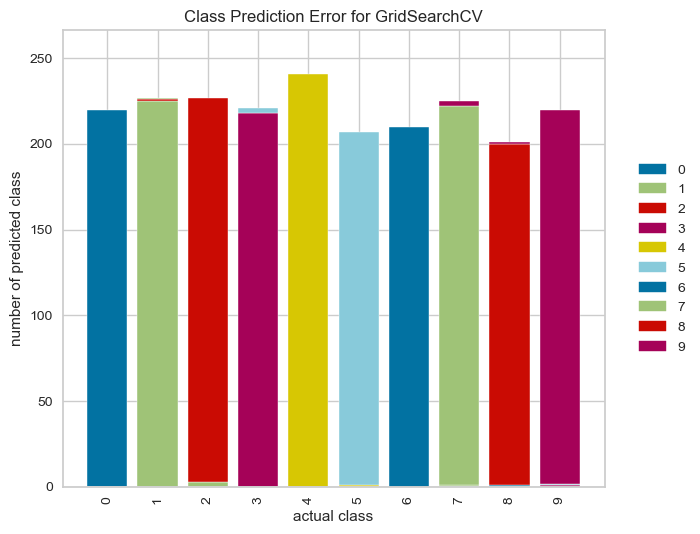

<Axes: title={'center': 'Class Prediction Error for GridSearchCV'}, xlabel='actual class', ylabel='number of predicted class'>

In [41]:
# peki hangi classda ne kadar hata yapmış ??
# Grafiklerden çoğu sınıfın doğru tahmin edildiğini görebiliriz. 
# Ancak model, 2-3-7 sınıflarını diğerlerine göre daha kötü tahmin etti.

visualizer = ClassPredictionError(SVM_model_grid)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

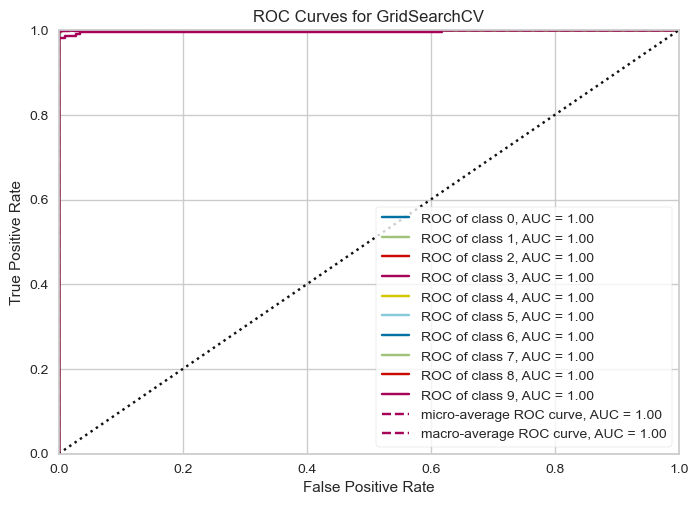

In [42]:
visualizer = ROCAUC(SVM_model_grid, classes=[str(i) for i in range(10)])

visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show();                      # Finalize and render the figure

**classes=[str(i) for i in range(10);**
Bir sınıflandırma problemi için sınıf etiketlerini belirtmek için kullanılır. classes parametresi, sınıf etiketlerini temsil eden bir liste alır. Burada range(10) 0'dan 9'a kadar olan sayıları içeren bir dizi oluşturur. str(i) ifadesi her sayıyı string olarak dönüştürür ve oluşan listeye ekler. Bu şekilde sınıf etiketleri string olarak belirlenir ve görselleştirme için kullanılır.

In [43]:
# Bu kod, multiclass log-loss (multiclass cross-entropy) metriğini kullanarak, 
# svm_model_grid modelinin test seti tahminlerinin performansını değerlendirir.

from sklearn.metrics import log_loss

y_pred = SVM_model_grid.predict_proba(X_test)
log_loss_score = log_loss(y_test, y_pred)
print("Log loss score: ", log_loss_score)

Log loss score:  0.033340115493253976


**Precision-recall eğrileri**, iki sınıflı (**binary**) sınıflandırma problemlerinde kullanılır.

Bu durumda, çok sınıflı sınıflandırma performansını değerlendirmek için, örneğin çok sınıflı log-loss gibi farklı bir metrik kullanabilirsiniz.

**Log loss**, sınıflandırma modellerinin performansını değerlendirmek için kullanılan bir metriktir. 

Doğru olarak adlandırılan olasılık skorlarına dayanarak bir modelin ne kadar iyi performans gösterdiğini ölçer. 

Özellikle, gerçek etiketlere (sınıflara) göre tahmin edilen olasılıkların ne kadar doğru olduğunu ölçer.

predict_proba() yöntemi, çok sınıflı sınıflandırma modellerinde, her bir sınıf için ayrı ayrı olasılık tahminleri yapar. Bu nedenle, svm_model_grid modelinden elde edilen tahminler, predict_proba() yöntemi kullanılarak y_pred değişkenine atılır.

Sonrasında, gerçek hedef değerleri olan y_test ile, log_loss() fonksiyonu kullanılarak karşılaştırılır ve bir log-loss skoru elde edilir. Log-loss skoru, modelin gerçek değerleri ne kadar iyi tahmin ettiğini ölçer ve skor ne kadar düşük olursa, model o kadar iyi performans gösterir.

Log-loss skoru, modelin gerçek değerleri ne kadar iyi tahmin ettiğini ölçer ve skor ne kadar düşük olursa, model o kadar iyi performans gösterir.

İdeal skor 0'dır, bu da mükemmel bir sınıflandırma anlamına gelir. Yüksek bir log kaybı değeri, modelin tahminlerinin gerçek etiketlerden oldukça farklı olduğunu gösterir.

Log kaybı, modelin sadece doğru veya yanlış tahminlerini değil, aynı zamanda bu tahminlerin ne kadar emin olduğunu da dikkate alır. Bu nedenle, özellikle olasılık tahminleri almak istediğiniz durumlarda log kaybını kullanmak yararlıdır.

SVM, Logistic Regression, Decision Trees, Random Forest, GB, XGBoost, KNN gibi modellerle kullanılabilir.

## Implement Decision Tree Classifier

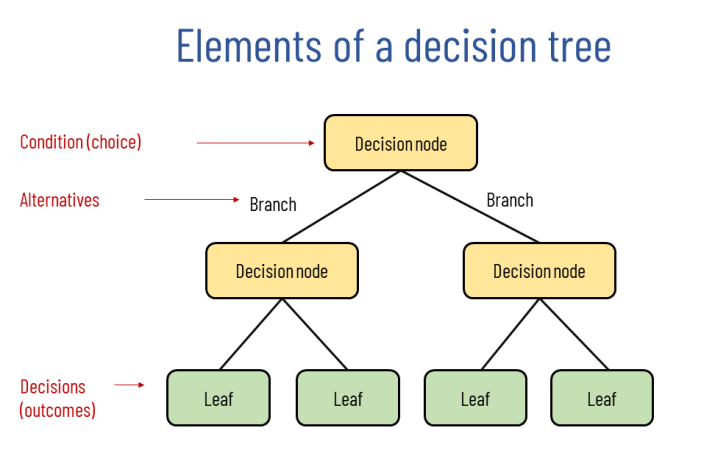

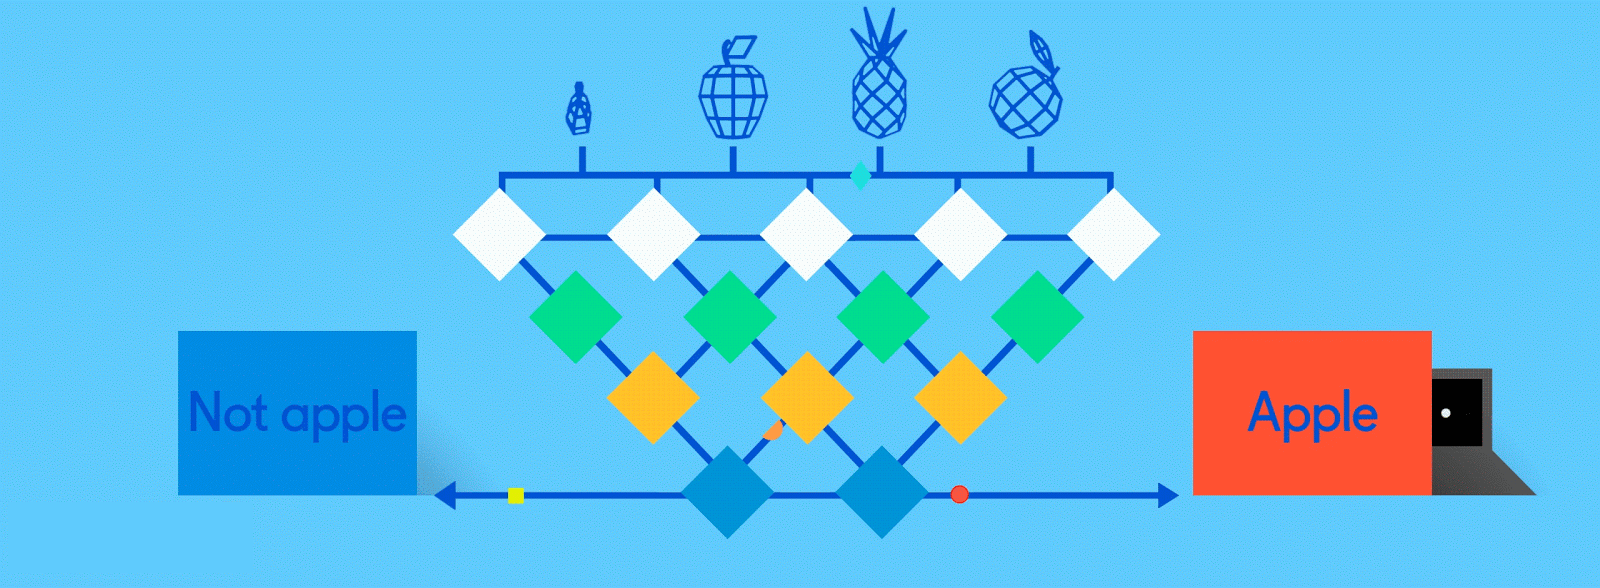

**Decision Tree (Karar Ağaçları) Temelleri**

 - Karar Ağaçları, özelliklerin belirli bir sıralamaya veya hiyerarşiye dayalı olarak ayrıldığı hiyerarşik bir yapıdır. Ağaç, en üstteki root node ile başlar ve sonunda hedef değişkenin değerlerine karşılık gelen son düğümlere (leaf node) bölünür.
 - Her bir düğümde, bir özellik belirli bir kriter (genellikle bir eşik değer) temelinde veriyi ikiye böler. Bu bölünme kriteri, genellikle information gane, Gini impurity veya entropy gibi metriklere dayanır.

1. **Tanım**: Karar ağaçları, sınıflandırma ve regresyon problemleri için kullanılan, görsel olarak anlaşılması kolay ve yorumlanabilir modellerdir. Bir karar ağacı, verileri daha küçük alt kümelere bölerken, aynı zamanda bir dizi karar kuralını uygular.

2. **Çalışma Prensibi**: Bir karar ağacı, en üstte bir root node (kök düğüm) ile başlar ve feature lara dayalı olarak veri setini bölerek alt dallara ayrılır. Her dal, veri setinin bir özelliğine göre yapılan bir karara karşılık gelir ve bu dallar, leaf node (yaprak düğüm) veya sonuç düğümlerine kadar devam eder.

3. **Bölme Kriterleri**: Karar ağaçları, veri setini en iyi şekilde ayıracak özellikleri ve bölme noktalarını belirlemek için çeşitli algoritmalar kullanır. En yaygın bölme kriterleri Gini impurity, entropy ve information gain'dir.

Tabii ki, Gini index, information gain ve entropi, karar ağaçlarında bölünmeleri belirlemek için kullanılan üç önemli metriktir. Her birinin ne olduğunu ve aralarındaki ilişkiyi açıklayalım:

**Entropi**
- **Tanımı**: Entropi, bir sistemin düzensizliğini veya belirsizliğini ölçer. Karar ağacı bağlamında, bir düğümdeki sınıfların ne kadar karışık olduğunu gösterir.

- **Kullanım**: Bir düğümün entropisi yüksekse, bu düğümdeki veriler karışıktır ve daha fazla bölünme gereklidir.

**Information Gain**
- **Tanımı**: Information gain, bir özelliğin bölünmesi sonucunda entropideki azalmayı ölçer. Yani, bir özelliği kullanarak veri setini bölmenin ne kadar "bilgi" sağladığını ifade eder.
- **Hesaplama**: Bir özelliğin information gain'i, özelliğin kullanılmasıyla elde edilen entropi azalmasına eşittir:
  \[ Information Gain = Entropi(önce) - Entropi(sonra) \]
- **Kullanım**: Bir özellik yüksek information gain'e sahipse, bu özelliğin veri setini etkili bir şekilde böleceği anlamına gelir ve karar ağacında bu özellik tercih edilir.

**Gini Index (Gini Impurity)**
- **Tanımı**: Gini index, bir düğümdeki sınıfların ne kadar sık karıştığını ölçer. Düşük Gini index değeri, düğümdeki sınıfların daha homojen olduğunu gösterir.

- **Kullanım**: Gini index'i düşük olan bir özellik, sınıfların daha iyi ayrıldığı ve dolayısıyla tercih edilen bir bölünme sağladığı anlamına gelir.

**İlişkiler ve Farklar**
- **Entropi ve Information Gain**: Entropi, düğümün karışıklık derecesini ölçerken, information gain bu karışıklığın bir özellik tarafından ne kadar azaltıldığını ölçer. Yüksek information gain, entropide büyük bir azalma anlamına gelir.
- **Gini Index ve Entropi**: Hem Gini index hem de entropi, bir düğümdeki saflığı ölçer, ancak farklı formüller kullanır. Gini genellikle daha hızlı hesaplanır ve bu nedenle büyük veri setleri için tercih edilebilir.
- **Seçim**: Karar ağaçları oluşturulurken, Gini index ve entropi arasında seçim yapılır. Her ikisi de benzer sonuçlar verebilir, ancak farklı veri setlerinde ve durumlarda farklı performans gösterebilirler. 

**Karar Ağaçlarının Avantajları ve Dezavantajları**

**Avantajları:**
- **Anlaşılması Kolay**: Karar ağaçları, modelin nasıl bir tahminde bulunduğunu anlamayı kolaylaştırır.
- **Veri Ön İşleme Gereksinimi Az**: Normalizasyon veya ölçeklendirme gibi veri ön işleme adımlarına genellikle ihtiyaç duymazlar.

**Dezavantajları:**
- **Aşırı Uydurma (Overfitting) Eğilimi**: Karar ağaçları, eğitim verilerine overfitting sağlayabilir, bu da modelin genelleştirme yeteneğini azaltır.
- **Karar Ağacının Kararlılığı**: Veri setindeki küçük değişiklikler, ağacın yapısında büyük değişikliklere yol açabilir.

**Uygulamalar ve Geliştirmeler**

- **Random Forest ve Boosting Yöntemleri**: Bu yöntemler, karar ağaçlarının overfitting sorununu azaltmaya yardımcı olur. Random Forest, birden fazla karar ağacını birleştirirken, boosting yöntemleri zayıf karar ağaçlarını iteratif olarak güçlendirir.
- **Feature importance**: Karar Ağaçları, her bir özelliğin hedef değişken üzerindeki etkisini ölçmek için bir "feature importance" sağlar. Bu, hangi özelliklerin model için en önemli olduğunu anlamanıza yardımcı olur.
- **Uygulama Alanları**: Karar ağaçları, müşteri segmentasyonu, kredi riski değerlendirmesi, tıbbi teşhis ve daha pek çok alanda kullanılır.

**İyi Uygulamalar**

- **Ağacın Derinliğini Sınırlama**: Aşırı uyumu önlemek için ağacın derinliğini sınırlamak önemlidir.
- **Pruning (Budama)**: Ağacın büyümesini kontrol altında tutmak ve overfitting'i azaltmak için budama teknikleri kullanılır.
- **Cross validation**: Modelin genelleştirme yeteneğini değerlendirmek için cross validation teknikleri kullanılmalıdır.

### Vanilla DT

In [44]:
DT_model = DecisionTreeClassifier(random_state=101)

DT_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=101)

In [45]:
y_pred_test = DT_model.predict(X_test)
y_pred_train = DT_model.predict(X_train)

In [46]:
DT_accuracy_test = accuracy_score(y_test, y_pred_test)
DT_accuracy_train = accuracy_score(y_train, y_pred_train)

DT_f1_test = f1_score(y_test, y_pred_test, average='macro')
DT_f1_train = f1_score(y_train, y_pred_train, average='macro')

DT_accuracy_test, DT_accuracy_train, DT_f1_test, DT_f1_train

rfc_accuracy_test = accuracy_score(y_test, y_pred_test)
rfc_accuracy_train = accuracy_score(y_train, y_pred_train)

rfc_f1_test = f1_score(y_test, y_pred_test, average='macro')
rfc_f1_train = f1_score(y_train, y_pred_train, average='macro')

rfc_accuracy_test, rfc_accuracy_train, rfc_f1_test, rfc_f1_train

(0.9472487494315598, 1.0, 0.9472437195988315, 1.0)

In [47]:
print("TEST REPORT")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, digits = 3))


print("\n"*3, "-*"*30)
print("TRAIN REPORT")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train, digits = 3))

TEST REPORT
[[220   0   0   0   0   0   1   0   0   0]
 [  0 211  16   1   1   0   0   0   0   0]
 [  0   5 216   0   0   1   0   3   0   0]
 [  0   6   1 207   0   3   0   0   0   2]
 [  0   0   0   0 236   4   0   0   0   2]
 [  0   0   0   7   1 194   0   1   1   6]
 [  4   1   1   0   0   2 198   0   3   1]
 [  0  10   5   2   0   0   3 201   1   0]
 [  7   0   0   0   0   1   0   0 191   0]
 [  0   0   0   2   1   5   0   4   1 209]]
              precision    recall  f1-score   support

           0      0.952     0.995     0.973       221
           1      0.906     0.921     0.913       229
           2      0.904     0.960     0.931       225
           3      0.945     0.945     0.945       219
           4      0.987     0.975     0.981       242
           5      0.924     0.924     0.924       210
           6      0.980     0.943     0.961       210
           7      0.962     0.905     0.933       222
           8      0.970     0.960     0.965       199
           9    

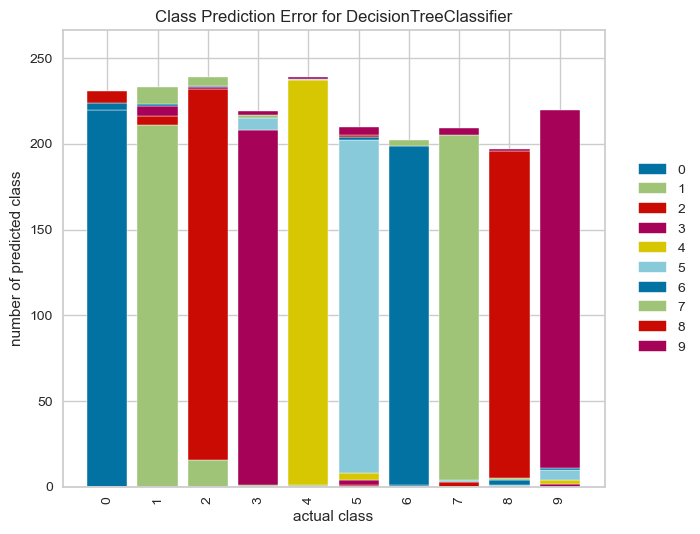

<Axes: title={'center': 'Class Prediction Error for DecisionTreeClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [48]:
visualizer = ClassPredictionError(DT_model)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

### DT GridsearchCV

1. **criterion**: Karar ağacının her bir bölünmesini değerlendirmek için kullanılan metriği belirtir. Genellikle iki değer alır:
   - **Entropy**: Bilgi kazancına dayanır ve veri setinin düzensizliğini ölçer. Daha yüksek entropi, daha fazla düzensizlik anlamına gelir.
   - **Gini**: Gini impurity (saf olmayanlık) kullanılır ve bir düğümdeki sınıfların ne kadar karışık olduğunu gösterir. Düşük Gini değeri daha iyi bir ayrım sağlar.

2. **splitter**: Her düğümde bölünme stratejisini belirler. İki temel seçenek vardır:
   - **"best"**: Her düğümde en iyi bölünmeyi (en düşük Gini ya da entropi) bulur.
   - **"random"**: Rastgele bölünmeler seçer, bu da modelin daha fazla varyansı olmasına neden olabilir.

3. **max_depth**: Ağacın maksimum derinliğini belirtir. Bu parametre, kök düğümden yaprak düğümlerine kadar olan maksimum düzey sayısını sınırlandırır. Değer olarak genellikle bir pozitif tamsayı alır veya 'None' olarak bırakılırsa sınırsız derinliğe izin verir. Sınırlı bir derinlik, modelin overfitting yapmasını önlemeye yardımcı olabilir.

4. **max_features**: Her bölünmede dikkate alınacak maksimum özellik sayısını belirtir. Değerler şunlar olabilir:
   - Tamsayı (n): Maksimum n özellik.
   - Ondalık (0.0 - 1.0 arası): Özelliklerin yüzdesi.
   - **"auto"**: Tüm özellikleri kullanır.
   - **"sqrt"**: Özellik sayısının karekökünü kullanır.
   - **"log2"**: Özellik sayısının log2'sini kullanır.

5. **max_leaf_nodes**: Oluşturulacak maksimum yaprak düğüm sayısını belirtir. Bu parametre, bir tamsayı değeri alabilir veya 'None' bırakılabilir (sınırsız yaprak düğümüne izin verir).  Modelin karmaşıklığını ve overfittinge gitmesini kontrol etmek için kullanılır.

6. **min_samples_leaf**: Bir yaprak düğümde bulunması gereken minimum örnek (sample) sayısını belirtir. Genellikle bir tamsayı veya her bir düğümdeki örneklerin minimum yüzdesi olarak belirlenir. modelin overfitting olmasını önlemek için yaprak düğümlerinin çok küçük olmasını engeller.

7. **min_samples_split**: Bir düğümün bölünmesi için gereken minimum örnek sayısını belirtir. Bu da genellikle bir tamsayı veya bölünme için gerekli olan minimum örnek yüzdesi olarak ayarlanır.Bu parametre de overfittingi önlemek için kullanılır, çünkü çok az sayıda örneğe sahip düğümler modelin veriye overfitting olmasına yol açabilir.

In [49]:
param_grid = {
             'criterion': ["entropy","gini"],
             'max_depth':[7,8],
             'max_features':['auto', 0.8],
             'max_leaf_nodes': [180,200],
             }

In [50]:
DT_model = DecisionTreeClassifier()
DT_grid_model = GridSearchCV(DT_model,
                             param_grid,
                             verbose=2,
                             scoring="accuracy",
                             n_jobs=-1)

DT_grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'], 'max_depth': [7, 8],
                         'max_features': ['auto', 0.8],
                         'max_leaf_nodes': [180, 200]},
             scoring='accuracy', verbose=2)

In [51]:
DT_grid_model.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 0.8,
 'max_leaf_nodes': 180}

In [52]:
y_pred_test = DT_grid_model.predict(X_test)
y_pred_train = DT_grid_model.predict(X_train)

In [53]:
DT_accuracy_test = accuracy_score(y_test, y_pred_test)
DT_accuracy_train = accuracy_score(y_train, y_pred_train)

DT_f1_test = f1_score(y_test, y_pred_test, average='macro')
DT_f1_train = f1_score(y_train, y_pred_train, average='macro')

DT_accuracy_test, DT_accuracy_train, DT_f1_test, DT_f1_train

(0.927694406548431, 0.9648584100989424, 0.9278096672362848, 0.9646826401539924)

In [54]:
print("TEST CM\n" , confusion_matrix(y_test, y_pred_test))
print("-*"*30)
print("TRAIN CM \n", confusion_matrix(y_train, y_pred_train))
print("-*"*30)
print("TEST REPORT \n", classification_report(y_test, y_pred_test, digits= 3))
print("-*"*30)
print("TRAIN REPORT \n", classification_report(y_train, y_pred_train, digits= 3))

TEST CM
 [[213   0   0   0   0   0   2   0   6   0]
 [  0 204  21   2   0   0   0   2   0   0]
 [  0   5 214   3   0   1   2   0   0   0]
 [  0   1   1 211   0   1   1   0   0   4]
 [  2   1   0   0 221   0   2   0   0  16]
 [  0   2   0   9   0 164   0   1   1  33]
 [  0   0   2   0   1   4 202   0   1   0]
 [  0   8   1   5   0   0   1 198   5   4]
 [  1   0   0   0   0   1   0   0 197   0]
 [  0   0   0   1   0   1   0   3   1 216]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
TRAIN CM 
 [[919   0   0   0   1   1   0   0   1   0]
 [  0 839  38  22   0   1   0  13   0   1]
 [  0  14 896   7   0   2   0   0   0   0]
 [  0   3   4 824   1   0   0   0   0   4]
 [  0   2   0   0 874   0   8   0   0  18]
 [  0   0   0   7   2 758   0   0   1  77]
 [  0   4   0   1   4   1 836   0   0   0]
 [  0   0   5  46   0   0   1 863   2   3]
 [  0   0   0   2   0   0   0   0 854   0]
 [  0   4   0   2   1   2   1   1   1 821]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-

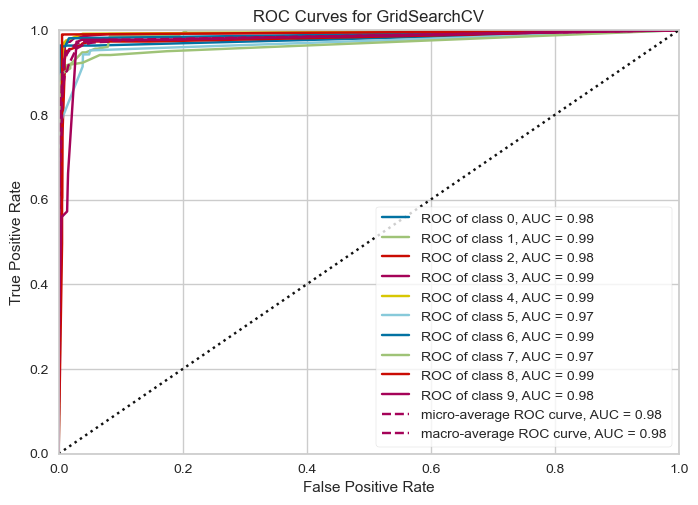

<Axes: title={'center': 'ROC Curves for GridSearchCV'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [55]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(DT_grid_model, classes=[str(i) for i in range(10)])

visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()                       # Finalize and render the figure

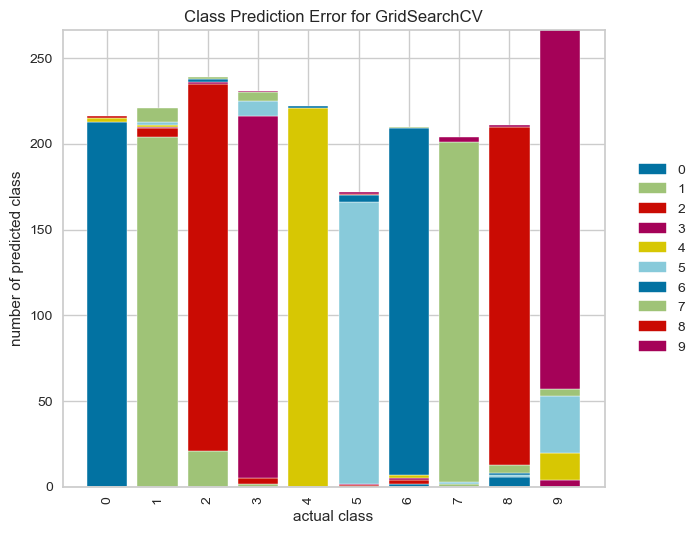

<Axes: title={'center': 'Class Prediction Error for GridSearchCV'}, xlabel='actual class', ylabel='number of predicted class'>

In [56]:
visualizer = ClassPredictionError(DT_grid_model)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

## Implement Random Forest Classifier


Random Forest ile Decision Tree nin dezavantajları ortadan kaldırılır.

**Random Forest**; birden çok karar ağacı üzerinden her bir karar ağacını farklı bir gözlem örneği üzerinde eğiterek çeşitli modeller üretip, sınıflandırma oluşturmanızı sağlamaktadır.

DT de en güçlü feature kullanılarak tahminlerde bulunulur bu da varyans arttırımına yani overfittinge neden olur. Bu durumun önüne geçmek için geliştirilmiştir.

Kural tabanlı bir yaklaşım kullandığı için verilerin normalleştirilmesi gerekli değildir.

Yapısal olarak oluşturmuş olduğu fazlaca çözüm (Ağaç) sayısından dolayı biraz yavaş sonuç üretmektedir, (Eğitim hızlı, tahmin uzun)(Özellikle gerçek zamanlı tahminlemeler için)

Random Forest ta train setin belirli oranda random olarak alınan herbir alt kümesi için fetaures larıda random olarak alarak ayrı ayrı DT modelleri kurar. Yani her seferinde aynı güçlü fetaure kullanılmıyor ve her seferinde random olarak alınan fetaure lar kullanılıyor.

### Vanilla RF

In [57]:
rfc = RandomForestClassifier(n_estimators=100, random_state=101)

rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=101)

In [58]:
y_pred_test = rfc.predict(X_test)
y_pred_train = rfc.predict(X_train)

In [59]:
rfc_accuracy_test = accuracy_score(y_test, y_pred_test)
rfc_accuracy_train = accuracy_score(y_train, y_pred_train)

rfc_f1_test = f1_score(y_test, y_pred_test, average='macro')
rfc_f1_train = f1_score(y_train, y_pred_train, average='macro')

rfc_accuracy_test, rfc_accuracy_train, rfc_f1_test, rfc_f1_train

(0.9863574351978172, 1.0, 0.9864386100351128, 1.0)

In [60]:
print("TEST REPORT")
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, digits = 3))


print("\n"*3, "-*"*30)
print("TRAIN REPORT")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train, digits = 3))

TEST REPORT
[[218   0   0   0   0   0   0   0   3   0]
 [  0 216  12   0   0   0   0   1   0   0]
 [  0   1 222   1   0   0   0   1   0   0]
 [  0   0   0 219   0   0   0   0   0   0]
 [  0   0   0   0 242   0   0   0   0   0]
 [  0   0   0   3   0 205   0   0   0   2]
 [  0   0   0   0   0   0 210   0   0   0]
 [  0   1   1   0   0   0   1 219   0   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   0   0   0   0   0   0   2   1 219]]
              precision    recall  f1-score   support

           0      1.000     0.986     0.993       221
           1      0.991     0.943     0.966       229
           2      0.945     0.987     0.965       225
           3      0.982     1.000     0.991       219
           4      1.000     1.000     1.000       242
           5      1.000     0.976     0.988       210
           6      0.995     1.000     0.998       210
           7      0.982     0.986     0.984       222
           8      0.980     1.000     0.990       199
           9    

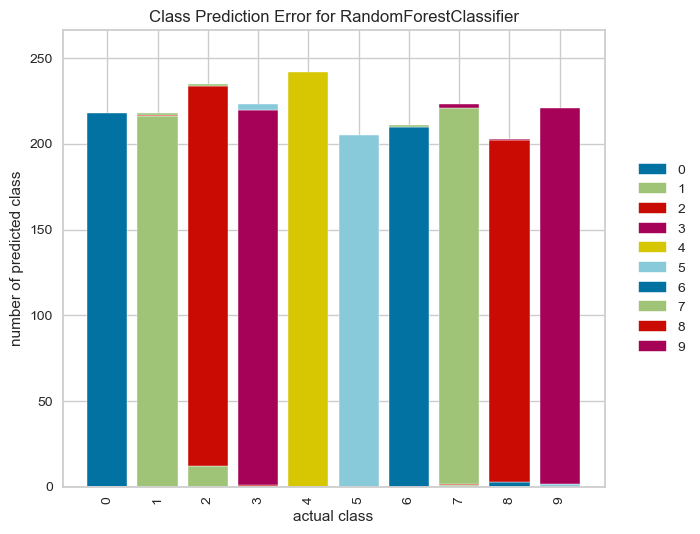

<Axes: title={'center': 'Class Prediction Error for RandomForestClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [61]:
visualizer = ClassPredictionError(rfc)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

### RF GridsearchCV

**RF HyperParameters**

**1- N_ESTIMATORS:** Modelin kaç adet karar ağacı kullanacağını belirler. "Modelimde kac tane agac modeli olsun?" RandomForest icin en onemli parametredir. (Default=100) sub sample ile datanın 2/3 ile oluşturuyor!!

**2- CRITERION = GINI :** bir düğümdeki sınıfların heterojenliğini ölçer. Bulundugu bolgedeki yanlis hesaplamanin degerini minimize etmeye calisir. Bu yuzden gini kucukse, hata da kucuk demektir. Basari arttikca gini 0' a yaklasir. Tum class' lari mukemmel ayirdigi noktada gini=0 olur.

**ENTROPY :** bir düğümdeki sınıfların belirsizliğini ölçer, bilgi miktarını (information gain) ifade eder. Bir düğümdeki sınıfların homojen olması durumunda entropy değeri düşük olacaktır. Yani, bir düğümde sınıfların tamamı aynıysa, o zaman entropy değeri sıfıra yakın olacaktır. Kısaca Kaos demektir. Kaosun en az olmasini isteriz.!!!

Basari orani arttikca gini ve entropy 0' a yaklasir. !!!

**3- MAX_DEPTH:** Karar ağacının maksimum derinliğini belirleyen bir hiperparametredir. Agac ne kadar derinlige insin? (Oklarin adim sayisi)(Bias ekleme islemi)

**4- MIN_SAMPLES_SPLIT :** Bir düğümün yaprağın bölünmeden önce kaç örneğe sahip olması gerektiğini belirleyen bir hiperparametredir. Bir yapragin bolunebilmesi icin o yaprakta bulunmasi gereken sample sayisi. Default degeri=2. Yani, sample sayisi en az 2 ise bolunmeye devam et. Hata kaldiysa bolmeye devam eder, kalmadiysa durur. Ayarlamasi cok fazla dikkat gerektirir. Bu yuzden ilk asamadad egistirilmesi tercih edilmez.

**5- MAX_FEATURES:** Tek bir ağaçta kullanılacak maksimum feature sayısıdır. Tum feature'lari gezerek "En iyi soruyu hangi feature'a sorabilirim?" diyor fakat bu parametrenin Decision Tree modelden farki: Feature sayisinin karekokunu alir o kadar feature icinden en iyisini secer ve yoluna devam eder. Mesela 8 feature varsa onun karekokunu alir ve int olarak alt sayiya yuvarlar; yani degeri 2 olarak kabul eder ve bunlar arasindan en iyifeature' i secer. Boylece overfitting' ' Decision Tree Model' e gore onlemis olur.(Default='auto')!!

**6- MAX_LEAF_NODE:** Bir karar ağacının oluşturabileceği maksimum yaprak (leaf) düğüm sayısını belirler.

**7- BOOTSTRAP:** Modelimi Random Tree Model yapan bu parametredir. Datadaki sample sayisini her bir agac icin rastgele 2/3 oraninda ayirir ve onlar icinden max_feature'a gore subsample'lar secerek agaclar olusturur. Böylece, oluşturulan her bir karar ağacı, farklı bir alt küme üzerinde eğitilir.Her bir ağacın birbirinden bağımsız olmasını ve daha farklı özelliklerin öğrenilmesini sağlar. Rastgele secim yaptigi icin train setinde daha iyi genellestirme yapar ve skorlar iyilesir.(Default=True)

**8- CLASS_WEIGHT :** Istenirse Logistic Regression' daki gibi bir balance islemi uygulanabilir. (Default=None)

**9- MAX_SAMPLES:** 'none' dedigimizde butun datadaki verileri alir ama 0.8dedigimizde datanin %80' ini alir ve sonra Random Forest bu %80' in 2/3' unualir. Yani her agaca sample verirken datanin %80' ini verir. (Default=None)

In [62]:
param_grid = {
             'criterion': ["entropy","gini"],
             'max_depth':[7,8],
             'max_features':['auto', 0.8],
             'max_leaf_nodes': [180,200],
             'n_estimators':[50,100],
             }

In [63]:
rf_model = RandomForestClassifier()
rf_grid_model = GridSearchCV(rf_model,
                             param_grid,
                             verbose=2,
                             scoring="accuracy",
                             n_jobs=-1)

rf_grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'], 'max_depth': [7, 8],
                         'max_features': ['auto', 0.8],
                         'max_leaf_nodes': [180, 200],
                         'n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

In [64]:
rf_grid_model.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 0.8,
 'max_leaf_nodes': 180,
 'n_estimators': 100}

In [65]:
y_pred_test = rf_grid_model.predict(X_test)
y_pred_train = rf_grid_model.predict(X_train)

In [66]:
rfc_accuracy_test = accuracy_score(y_test, y_pred_test)
rfc_accuracy_train = accuracy_score(y_train, y_pred_train)

rfc_f1_test = f1_score(y_test, y_pred_test, average='macro')
rfc_f1_train = f1_score(y_train, y_pred_train, average='macro')

rfc_accuracy_test, rfc_accuracy_train, rfc_f1_test, rfc_f1_train

(0.977262391996362, 0.9936312976231093, 0.9773749290358026, 0.9936682721807774)

In [67]:
print("TEST CM\n" , confusion_matrix(y_test, y_pred_test))
print("-*"*30)
print("TRAIN CM \n", confusion_matrix(y_train, y_pred_train))
print("-*"*30)
print("TEST REPORT \n", classification_report(y_test, y_pred_test, digits= 3))
print("-*"*30)
print("TRAIN REPORT \n", classification_report(y_train, y_pred_train, digits= 3))

TEST CM
 [[219   0   0   0   0   0   0   0   2   0]
 [  0 215  13   0   0   0   0   1   0   0]
 [  0   1 221   1   0   0   0   2   0   0]
 [  0   1   0 217   0   1   0   0   0   0]
 [  0   0   0   0 240   0   0   0   0   2]
 [  0   0   0   4   0 200   0   0   1   5]
 [  0   0   0   0   0   0 209   0   1   0]
 [  0   5   1   2   0   0   0 213   1   0]
 [  0   0   0   0   0   0   0   0 199   0]
 [  0   1   0   2   0   0   0   2   1 216]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*
TRAIN CM 
 [[922   0   0   0   0   0   0   0   0   0]
 [  0 884  17  13   0   0   0   0   0   0]
 [  0   0 916   2   0   0   0   1   0   0]
 [  0   4   2 827   0   1   0   2   0   0]
 [  0   1   0   0 899   0   0   0   0   2]
 [  0   0   0   1   0 843   0   0   0   1]
 [  0   0   0   0   0   1 845   0   0   0]
 [  0   1   1   2   0   0   0 916   0   0]
 [  0   0   0   0   0   0   0   0 856   0]
 [  0   1   0   2   1   0   0   0   0 829]]
-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-*-

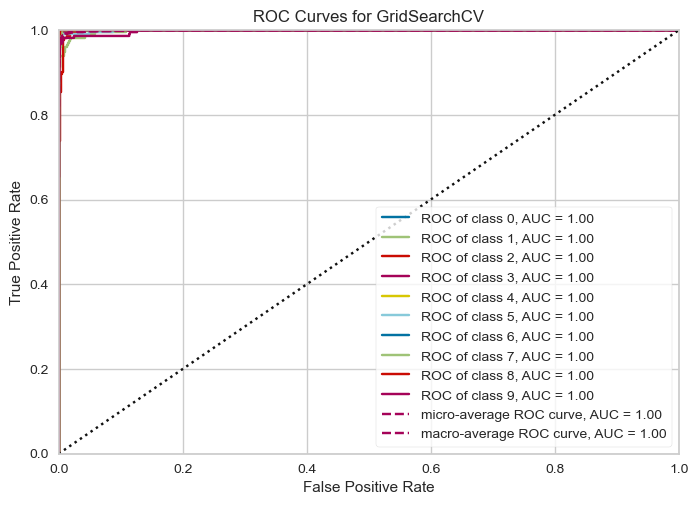

<Axes: title={'center': 'ROC Curves for GridSearchCV'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [68]:
from yellowbrick.classifier import ROCAUC

visualizer = ROCAUC(rf_grid_model, classes=[str(i) for i in range(10)])

visualizer.fit(X_train, y_train)        # Fit the training data to the visualizer
visualizer.score(X_test, y_test)        # Evaluate the model on the test data
visualizer.show()                       # Finalize and render the figure

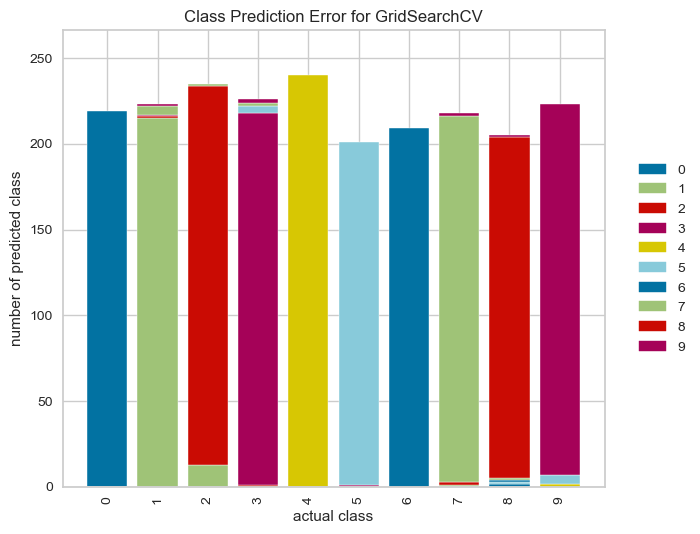

<Axes: title={'center': 'Class Prediction Error for GridSearchCV'}, xlabel='actual class', ylabel='number of predicted class'>

In [69]:
visualizer = ClassPredictionError(rf_grid_model)

# Fit the training data to the visualizer
visualizer.fit(X_train, y_train)

# Evaluate the model on the test data
visualizer.score(X_test, y_test)

# Draw visualization
visualizer.show()

# Compare The Models

## Accuracy Comparison

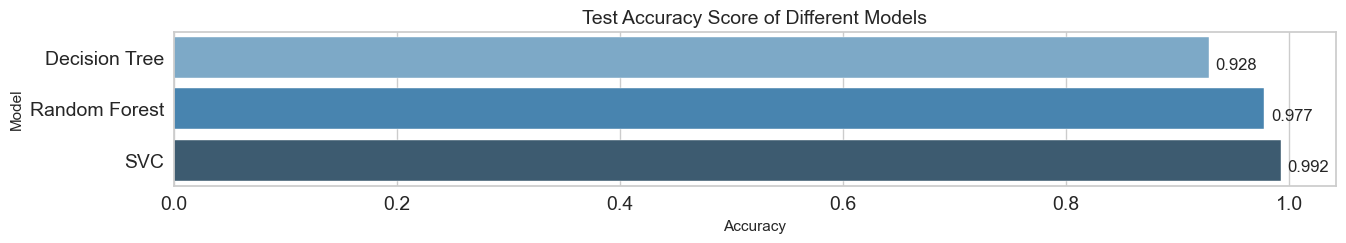

In [70]:
compare = pd.DataFrame({"Model": ["SVC", "Decision Tree", "Random Forest"],
                        "Accuracy": [SVM_accuracy_test, DT_accuracy_test, rfc_accuracy_test]})

compare = compare.sort_values(by="Accuracy", ascending=True)

plt.figure(figsize=(15,2))
ax = sns.barplot(x="Accuracy", y="Model", data=compare, palette="Blues_d")
for p in ax.patches:
    ax.annotate("%.3f" % p.get_width(), (p.get_x() + p.get_width(), p.get_y() + 0.9),
                xytext=(5, 10), textcoords='offset points')

plt.yticks(size = 14)
plt.xticks(size = 14)
plt.title("Test Accuracy Score of Different Models", size=14);

## F1 Score Comparison

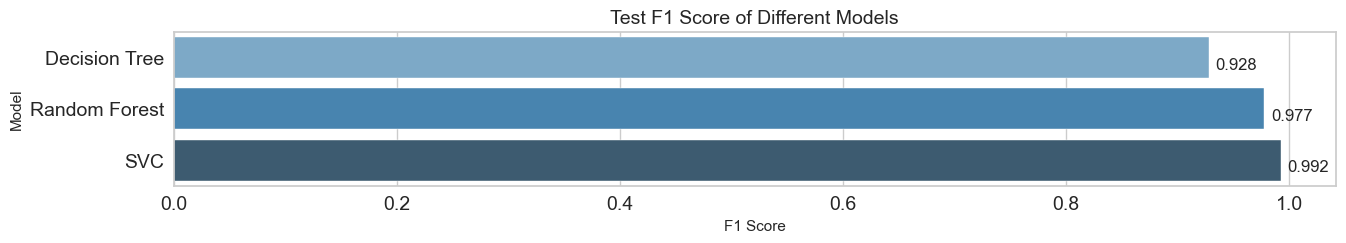

In [71]:
compare = pd.DataFrame({"Model": ["SVC", "Decision Tree", "Random Forest"],
                        "F1 Score": [svm_f1_test, DT_f1_test, rfc_f1_test]})

compare = compare.sort_values(by="F1 Score", ascending=True)

plt.figure(figsize=(15,2))
ax = sns.barplot(x="F1 Score", y="Model", data=compare, palette="Blues_d")
for p in ax.patches:
    ax.annotate("%.3f" % p.get_width(), (p.get_x() + p.get_width(), p.get_y() + .9),
                xytext=(5, 10), textcoords='offset points')

plt.yticks(size = 14)
plt.xticks(size = 14)
plt.title("Test F1 Score of Different Models", size=14);